In [1]:
import importlib
import platform
from importlib.metadata import PackageNotFoundError, version as _version


def version_paquete(nombre_modulo, nombre_distribucion):
    """Devuelve __version__ del módulo o consulta distribuciones de respaldo."""
    try:
        modulo = importlib.import_module(nombre_modulo)
    except (ImportError, OSError):
        modulo = None

    if modulo is not None:
        version_modulo = getattr(modulo, "__version__", None)
        if version_modulo is not None:
            return str(version_modulo)

    candidatos = (
        nombre_distribucion,
        f"{nombre_distribucion}-cpu",
        f"{nombre_distribucion}-intel",
        f"{nombre_distribucion}-macos",
        nombre_distribucion.replace("-", "_"),
    )
    for candidato in dict.fromkeys(candidatos):
        try:
            return _version(candidato)
        except PackageNotFoundError:
            continue
    return "no disponible"


VERSIONES_ENTORNO = {
    "python": platform.python_version(),
    "tensorflow": version_paquete("tensorflow", "tensorflow"),
    "numpy": version_paquete("numpy", "numpy"),
    "scikit-learn": version_paquete("sklearn", "scikit-learn"),
    "pandas": version_paquete("pandas", "pandas"),
    "scipy": version_paquete("scipy", "scipy"),
    "matplotlib": version_paquete("matplotlib", "matplotlib"),
    "shap": version_paquete("shap", "shap"),
    "tqdm": version_paquete("tqdm", "tqdm"),
    "ipywidgets": version_paquete("ipywidgets", "ipywidgets"),
}

print("Versiones del entorno de ejecución:")
for paquete, version in VERSIONES_ENTORNO.items():
    print(f"- {paquete}: {version}")

Versiones del entorno de ejecución:
- python: 3.11.9
- tensorflow: 2.21.0
- numpy: 2.3.5
- scikit-learn: 1.9.0
- pandas: 3.0.5
- scipy: 1.17.1
- matplotlib: 3.11.1
- shap: 0.51.0
- tqdm: 4.70.0
- ipywidgets: 8.1.8


In [2]:
import pandas as pd

df = pd.read_csv("universal_top_spotify_songs.csv")

df.shape
df.head()
df.info()
df.isnull().sum()
df.duplicated().sum()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2110316 entries, 0 to 2110315
Data columns (total 25 columns):
 #   Column              Dtype  
---  ------              -----  
 0   spotify_id          str    
 1   name                str    
 2   artists             str    
 3   daily_rank          int64  
 4   daily_movement      int64  
 5   weekly_movement     int64  
 6   country             str    
 7   snapshot_date       str    
 8   popularity          int64  
 9   is_explicit         bool   
 10  duration_ms         int64  
 11  album_name          str    
 12  album_release_date  str    
 13  danceability        float64
 14  energy              float64
 15  key                 int64  
 16  loudness            float64
 17  mode                int64  
 18  speechiness         float64
 19  acousticness        float64
 20  instrumentalness    float64
 21  liveness            float64
 22  valence             float64
 23  tempo               float64
 24  time_signature      int64  
dtypes:

,daily_rank,daily_movement,weekly_movement,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,2.110316e+06,2.110316e+06,2.110316e+06,2.110316e+06,2.110316e+06,2.110316e+06,2.110316e+06,2.110316e+06,2.110316e+06,2.110316e+06,2.110316e+06,2.110316e+06,2.110316e+06,2.110316e+06,2.110316e+06,2.110316e+06,2.110316e+06
mean,2.549302e+01,9.230660e-01,2.932522e+00,7.590713e+01,1.943095e+05,6.759191e-01,6.488031e-01,5.526496e+00,-6.772439e+00,5.364571e-01,9.550408e-02,2.748491e-01,2.316185e-02,1.705588e-01,5.462535e-01,1.221008e+02,3.900368e+00
std,1.442900e+01,7.015535e+00,1.233129e+01,1.576302e+01,4.986054e+04,1.440469e-01,1.689142e-01,3.594979e+00,3.874849e+00,4.986692e-01,9.138830e-02,2.509297e-01,1.137297e-01,1.247528e-01,2.311527e-01,2.781938e+01,4.044448e-01
min,1.000000e+00,-4.900000e+01,-4.900000e+01,0.000000e+00,0.000000e+00,0.000000e+00,2.010000e-05,0.000000e+00,-5.434100e+01,0.000000e+00,0.000000e+00,3.450000e-06,0.000000e+00,1.390000e-02,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.300000e+01,-1.000000e+00,-3.000000e+00,6.500000e+01,1.626370e+05,5.800000e-01,5.520000e-01,2.000000e+00,-7.830000e+00,0.000000e+00,3.840000e-02,6.670000e-02,0.000000e+00,9.610000e-02,3.700000e-01,1.000190e+02,4.000000e+00
50%,2.500000e+01,0.000000e+00,0.000000e+00,7.900000e+01,1.861910e+05,7.000000e-01,6.680000e-01,6.000000e+00,-6.064000e+00,1.000000e+00,5.810000e-02,1.910000e-01,1.340000e-06,1.220000e-01,5.480000e-01,1.199650e+02,4.000000e+00
75%,3.800000e+01,2.000000e+00,5.000000e+00,8.800000e+01,2.187010e+05,7.800000e-01,7.670000e-01,9.000000e+00,-4.723000e+00,1.000000e+00,1.120000e-01,4.370000e-01,1.010000e-04,2.040000e-01,7.330000e-01,1.400210e+02,4.000000e+00
max,5.000000e+01,4.900000e+01,4.900000e+01,1.000000e+02,1.296000e+06,9.880000e-01,9.980000e-01,1.100000e+01,3.233000e+00,1.000000e+00,9.570000e-01,9.960000e-01,9.950000e-01,9.830000e-01,9.920000e-01,2.360890e+02,5.000000e+00


## Diccionario de datos del dataset original

In [3]:
# ============================================================
# Diccionario de datos formal del dataset original de Spotify
# ============================================================

import pandas as pd

# Para visualizar mejor columnas largas en el notebook
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", None)

# Descripción de cada variable del dataset original
descripciones = {
    "spotify_id": "Identificador único de la canción en Spotify.",
    "name": "Nombre de la canción.",
    "artists": "Artista, grupo, banda o combinación de artistas asociados a la canción.",
    "daily_rank": "Posición diaria de la canción dentro del ranking de Spotify.",
    "daily_movement": "Variación de la posición de la canción respecto del día anterior.",
    "weekly_movement": "Variación de la posición de la canción respecto de la semana anterior.",
    "country": "País o mercado al que corresponde el ranking.",
    "snapshot_date": "Fecha en que fue capturado el ranking diario.",
    "popularity": "Índice de popularidad de la canción asignado por Spotify.",
    "is_explicit": "Indica si la canción contiene contenido explícito.",
    "duration_ms": "Duración de la canción expresada en milisegundos.",
    "album_name": "Nombre del álbum al que pertenece la canción.",
    "album_release_date": "Fecha de lanzamiento del álbum.",
    "danceability": "Medida de qué tan bailable es la canción, en escala de 0 a 1.",
    "energy": "Nivel de energía percibida de la canción, en escala de 0 a 1.",
    "key": "Tonalidad musical estimada de la canción.",
    "loudness": "Volumen promedio de la canción medido en decibeles.",
    "mode": "Modo musical de la canción, donde 1 suele representar modo mayor y 0 modo menor.",
    "speechiness": "Presencia de contenido hablado en la canción, en escala de 0 a 1.",
    "acousticness": "Probabilidad de que la canción sea acústica, en escala de 0 a 1.",
    "instrumentalness": "Probabilidad de que la canción sea instrumental, en escala de 0 a 1.",
    "liveness": "Probabilidad de que la canción haya sido interpretada en vivo, en escala de 0 a 1.",
    "valence": "Medida de positividad musical de la canción, en escala de 0 a 1.",
    "tempo": "Tempo estimado de la canción en beats por minuto.",
    "time_signature": "Compás musical estimado de la canción."
}

# Rango o valores esperados para cada variable
rangos_esperados = {
    "spotify_id": "Texto no nulo",
    "name": "Texto no nulo",
    "artists": "Texto no nulo",
    "daily_rank": "1 a 50",
    "daily_movement": "Valor entero, generalmente entre -49 y 49",
    "weekly_movement": "Valor entero, generalmente entre -49 y 49",
    "country": "Código de país o valor nulo si corresponde a ranking global",
    "snapshot_date": "Fecha válida",
    "popularity": "0 a 100",
    "is_explicit": "True o False",
    "duration_ms": "Mayor a 0",
    "album_name": "Texto",
    "album_release_date": "Fecha, año o valor textual según disponibilidad",
    "danceability": "0 a 1",
    "energy": "0 a 1",
    "key": "0 a 11",
    "loudness": "Valor numérico en decibeles",
    "mode": "0 o 1",
    "speechiness": "0 a 1",
    "acousticness": "0 a 1",
    "instrumentalness": "0 a 1",
    "liveness": "0 a 1",
    "valence": "0 a 1",
    "tempo": "Mayor a 0",
    "time_signature": "Valor entero, entre 1 y 5",
}

# Uso de cada variable dentro del proyecto
uso_proyecto = {
    "spotify_id": "Identificación y conteo de canciones únicas por artista; no usado como predictor directo.",
    "name": "Identificación descriptiva del nombre de la canción.",
    "artists": "Variable original usada para identificar a los artistas participantes. Las colaboraciones se separan antes de construir la base final por artista individual.",
    "daily_rank": "Variable central para calcular ranking promedio, mejor ranking y puntaje de posición en Chile.",
    "daily_movement": "Se usa para calcular el movimiento diario promedio.",
    "weekly_movement": "Se usa para calcular el movimiento semanal promedio.",
    "country": "Permite filtrar los registros correspondientes a Chile.",
    "snapshot_date": "Permite calcular la permanencia de canciones o artistas en el ranking.",
    "popularity": "Se usa como señal de popularidad promedio del artista.",
    "is_explicit": "Variable descriptiva. No se usa en el modelo final.",
    "duration_ms": "Variable descriptiva usada para revisar consistencia y posibles valores atípicos.",
    "album_name": "Variable descriptiva. No se usa en el modelo final.",
    "album_release_date": "Variable descriptiva. No se usa en el modelo final.",
    "danceability": "Variable musical disponible. No se usa en el modelo final, ya que el enfoque está en señales de ranking.",
    "energy": "Variable musical disponible. No se usa en el modelo final, ya que el enfoque está en señales de ranking.",
    "key": "Variable musical disponible. No se usa en el modelo final.",
    "loudness": "Variable musical disponible. No se usa en el modelo final.",
    "mode": "Variable musical disponible. No se usa en el modelo final.",
    "speechiness": "Variable musical disponible. No se usa en el modelo final.",
    "acousticness": "Variable musical disponible. No se usa en el modelo final.",
    "instrumentalness": "Variable musical disponible. No se usa en el modelo final.",
    "liveness": "Variable musical disponible. No se usa en el modelo final.",
    "valence": "Variable musical disponible. No se usa en el modelo final.",
    "tempo": "Variable musical disponible. No se usa en el modelo final.",
    "time_signature": "Variable musical disponible. No se usa en el modelo final."
}

# Construcción automática del diccionario de datos usando las columnas reales del DataFrame
diccionario_datos = pd.DataFrame({
    "Variable": df.columns,
    "Tipo de dato": [str(df[col].dtype) for col in df.columns],
    "Descripción": [descripciones.get(col, "Variable no descrita en el diccionario") for col in df.columns],
    "Rango esperado": [rangos_esperados.get(col, "No definido") for col in df.columns],
    "Valores nulos": [df[col].isnull().sum() for col in df.columns],
    "% de nulos": [round(df[col].isnull().mean() * 100, 2) for col in df.columns],
    "Valores únicos": [df[col].nunique(dropna=True) for col in df.columns],
    "Uso en el proyecto": [uso_proyecto.get(col, "No definido") for col in df.columns]
})

# Mostrar diccionario completo
diccionario_datos

,Variable,Tipo de dato,Descripción,Rango esperado,Valores nulos,% de nulos,Valores únicos,Uso en el proyecto
0,spotify_id,str,Identificador único de la canción en Spotify.,Texto no nulo,0,0.00,24983,Identificación y conteo de canciones únicas por artista; no usado como predictor directo.
1,name,str,Nombre de la canción.,Texto no nulo,30,0.00,21809,Identificación descriptiva del nombre de la canción.
2,artists,str,"Artista, grupo, banda o combinación de artistas asociados a la canción.",Texto no nulo,29,0.00,13726,Variable original usada para identificar a los artistas participantes. Las colaboraciones se separan antes de constr...
3,daily_rank,int64,Posición diaria de la canción dentro del ranking de Spotify.,1 a 50,0,0.00,50,"Variable central para calcular ranking promedio, mejor ranking y puntaje de posición en Chile."
4,daily_movement,int64,Variación de la posición de la canción respecto del día anterior.,"Valor entero, generalmente entre -49 y 49",0,0.00,99,Se usa para calcular el movimiento diario promedio.
5,weekly_movement,int64,Variación de la posición de la canción respecto de la semana anterior.,"Valor entero, generalmente entre -49 y 49",0,0.00,99,Se usa para calcular el movimiento semanal promedio.
6,country,str,País o mercado al que corresponde el ranking.,Código de país o valor nulo si corresponde a ranking global,28908,1.37,72,Permite filtrar los registros correspondientes a Chile.
7,snapshot_date,str,Fecha en que fue capturado el ranking diario.,Fecha válida,0,0.00,583,Permite calcular la permanencia de canciones o artistas en el ranking.
8,popularity,int64,Índice de popularidad de la canción asignado por Spotify.,0 a 100,0,0.00,101,Se usa como señal de popularidad promedio del artista.
9,is_explicit,bool,Indica si la canción contiene contenido explícito.,True o False,0,0.00,2,Variable descriptiva. No se usa en el modelo final.


### Interpretación del diccionario de datos

El diccionario de datos permite observar que el dataset original contiene 25 variables asociadas a identificación de canciones y artistas, ranking diario, país, fecha, popularidad y características musicales de Spotify.

Para el objetivo de este proyecto, las variables más relevantes son `artists`, `spotify_id`, `daily_rank`, `daily_movement`, `weekly_movement`, `country`, `snapshot_date` y `popularity`. Estas variables permiten identificar e individualizar a los artistas, contabilizar canciones únicas mediante su identificador de Spotify y construir las métricas agregadas utilizadas posteriormente para caracterizar el desempeño de cada artista en Chile.

Las variables musicales, como `danceability`, `energy`, `valence`, `tempo`, `acousticness` e `instrumentalness`, se mantienen como parte descriptiva del dataset, pero no se incorporan al modelo final, porque el foco metodológico está puesto en señales digitales locales derivadas del comportamiento en rankings diarios de Spotify Chile.

También se observa que la mayoría de las variables no presenta valores nulos relevantes. La columna `country` concentra valores nulos, los cuales fueron tratados como posibles registros globales o no asociados directamente a un país específico. Para el análisis local se filtraron únicamente los registros correspondientes a Chile mediante el código `CL`.

In [4]:
# ============================================================
# Versión resumida del diccionario para incluir en el informe
# ============================================================

# Clasificación general de cada variable
categoria_variable = {
    "spotify_id": "Identificación",
    "name": "Identificación",
    "artists": "Identificación",
    "daily_rank": "Ranking",
    "daily_movement": "Ranking",
    "weekly_movement": "Ranking",
    "country": "Ubicación",
    "snapshot_date": "Temporal",
    "popularity": "Popularidad",
    "is_explicit": "Descriptiva",
    "duration_ms": "Descriptiva",
    "album_name": "Descriptiva",
    "album_release_date": "Descriptiva",
    "danceability": "Característica musical",
    "energy": "Característica musical",
    "key": "Característica musical",
    "loudness": "Característica musical",
    "mode": "Característica musical",
    "speechiness": "Característica musical",
    "acousticness": "Característica musical",
    "instrumentalness": "Característica musical",
    "liveness": "Característica musical",
    "valence": "Característica musical",
    "tempo": "Característica musical",
    "time_signature": "Característica musical"
}

# Uso resumido para el informe
uso_resumido = {
    "spotify_id": "Identificación y conteo de canciones únicas por artista; no usado como predictor directo.",
    "name": "Identificación descriptiva del nombre de la canción.",
    "artists": "Identificación e individualización de artistas, incluyendo separación de colaboraciones.",
    "daily_rank": "Cálculo de ranking promedio, mejor ranking y puntaje local.",
    "daily_movement": "Cálculo de movimiento diario promedio.",
    "weekly_movement": "Cálculo de movimiento semanal promedio.",
    "country": "Filtro de registros correspondientes a Chile.",
    "snapshot_date": "Cálculo de permanencia en rankings.",
    "popularity": "Señal de popularidad promedio.",
    "is_explicit": "Variable descriptiva; no usada en el modelo final.",
    "duration_ms": "Revisión descriptiva y detección de posibles atípicos.",
    "album_name": "Variable descriptiva; no usada en el modelo final.",
    "album_release_date": "Variable descriptiva; no usada en el modelo final.",
    "danceability": "Variable musical disponible; no usada en el modelo final.",
    "energy": "Variable musical disponible; no usada en el modelo final.",
    "key": "Variable musical disponible; no usada en el modelo final.",
    "loudness": "Variable musical disponible; no usada en el modelo final.",
    "mode": "Variable musical disponible; no usada en el modelo final.",
    "speechiness": "Variable musical disponible; no usada en el modelo final.",
    "acousticness": "Variable musical disponible; no usada en el modelo final.",
    "instrumentalness": "Variable musical disponible; no usada en el modelo final.",
    "liveness": "Variable musical disponible; no usada en el modelo final.",
    "valence": "Variable musical disponible; no usada en el modelo final.",
    "tempo": "Variable musical disponible; no usada en el modelo final.",
    "time_signature": "Variable musical disponible; no usada en el modelo final."
}

# Construcción del diccionario resumido para el informe
diccionario_informe = pd.DataFrame({
    "Variable": df.columns,
    "Tipo": [str(df[col].dtype) for col in df.columns],
    "Descripción": [descripciones.get(col, "No definida") for col in df.columns],
    "Rango esperado": [rangos_esperados.get(col, "No definido") for col in df.columns],
    "Categoría": [categoria_variable.get(col, "No definida") for col in df.columns],
    "% nulos": [round(df[col].isnull().mean() * 100, 2) for col in df.columns],
    "Uso en el proyecto": [uso_resumido.get(col, "No definido") for col in df.columns]
})

diccionario_informe

,Variable,Tipo,Descripción,Rango esperado,Categoría,% nulos,Uso en el proyecto
0,spotify_id,str,Identificador único de la canción en Spotify.,Texto no nulo,Identificación,0.00,Identificación y conteo de canciones únicas por artista; no usado como predictor directo.
1,name,str,Nombre de la canción.,Texto no nulo,Identificación,0.00,Identificación descriptiva del nombre de la canción.
2,artists,str,"Artista, grupo, banda o combinación de artistas asociados a la canción.",Texto no nulo,Identificación,0.00,"Identificación e individualización de artistas, incluyendo separación de colaboraciones."
3,daily_rank,int64,Posición diaria de la canción dentro del ranking de Spotify.,1 a 50,Ranking,0.00,"Cálculo de ranking promedio, mejor ranking y puntaje local."
4,daily_movement,int64,Variación de la posición de la canción respecto del día anterior.,"Valor entero, generalmente entre -49 y 49",Ranking,0.00,Cálculo de movimiento diario promedio.
5,weekly_movement,int64,Variación de la posición de la canción respecto de la semana anterior.,"Valor entero, generalmente entre -49 y 49",Ranking,0.00,Cálculo de movimiento semanal promedio.
6,country,str,País o mercado al que corresponde el ranking.,Código de país o valor nulo si corresponde a ranking global,Ubicación,1.37,Filtro de registros correspondientes a Chile.
7,snapshot_date,str,Fecha en que fue capturado el ranking diario.,Fecha válida,Temporal,0.00,Cálculo de permanencia en rankings.
8,popularity,int64,Índice de popularidad de la canción asignado por Spotify.,0 a 100,Popularidad,0.00,Señal de popularidad promedio.
9,is_explicit,bool,Indica si la canción contiene contenido explícito.,True o False,Descriptiva,0.00,Variable descriptiva; no usada en el modelo final.


In [5]:
df["country"].nunique()
df["country"].unique()
df["snapshot_date"].min(), df["snapshot_date"].max()

('2023-10-18', '2025-06-11')

In [6]:
print("Cantidad de países:", df["country"].nunique())
print("Países:", df["country"].unique())
print("Rango de fechas:", df["snapshot_date"].min(), "a", df["snapshot_date"].max())

Cantidad de países: 72
Países: <StringArray>
[ nan, 'ZA', 'VN', 'VE', 'UY', 'US', 'UA', 'TW', 'TR', 'TH', 'SV', 'SK', 'SG',
 'SE', 'SA', 'RO', 'PY', 'PT', 'PL', 'PK', 'PH', 'PE', 'PA', 'NZ', 'NO', 'NL',
 'NI', 'NG', 'MY', 'MX', 'MA', 'LV', 'LU', 'LT', 'KZ', 'KR', 'JP', 'IT', 'IS',
 'IN', 'IL', 'IE', 'ID', 'HU', 'HN', 'HK', 'GT', 'GR', 'FR', 'FI', 'ES', 'EG',
 'EE', 'EC', 'DO', 'DK', 'DE', 'CZ', 'CR', 'CO', 'CL', 'CH', 'CA', 'BY', 'BR',
 'BO', 'BG', 'BE', 'AU', 'AT', 'AR', 'AE', 'GB']
Length: 73, dtype: str


Rango de fechas: 2023-10-18 a 2025-06-11


In [7]:
df["country"].isna().sum()

np.int64(28908)

In [8]:
print("Registros y columnas:", df.shape)
print("Cantidad de países:", df["country"].nunique())
print("Valores únicos en country:", len(df["country"].unique()))
print("Rango de fechas:", df["snapshot_date"].min(), "a", df["snapshot_date"].max())

missing_country = df["country"].isna().sum()
total = len(df)
print("Registros sin país:", missing_country)
print("Porcentaje sin país:", round(missing_country / total * 100, 2), "%")

Registros y columnas: (2110316, 25)
Cantidad de países: 72
Valores únicos en country: 73


Rango de fechas: 2023-10-18 a 2025-06-11
Registros sin país: 28908
Porcentaje sin país: 1.37 %


In [9]:
# Intento inicial descartado: el dataset no usa "Chile", sino el código "CL" 
# chile = df[df["country"] == "Chile"]

# chile.shape
# chile["snapshot_date"].min(), chile["snapshot_date"].max()
# chile["spotify_id"].nunique()
# chile["artists"].nunique()

In [10]:
chile = df[df["country"] == "CL"]

print("Registros de Chile:", chile.shape)
print("Rango de fechas Chile:", chile["snapshot_date"].min(), "a", chile["snapshot_date"].max())
print("Canciones únicas en Chile:", chile["spotify_id"].nunique())
print("Artistas únicos en Chile:", chile["artists"].nunique())

Registros de Chile: (29105, 25)
Rango de fechas Chile: 2023-10-18 a 2025-06-11
Canciones únicas en Chile: 599
Artistas únicos en Chile: 408


In [11]:
missing_country = df["country"].isna().sum()
total = len(df)
missing_percent = missing_country / total * 100

print("Registros sin país:", missing_country)
print("Porcentaje sin país:", round(missing_percent, 2), "%")

Registros sin país: 28908
Porcentaje sin país: 1.37 %


In [12]:
global_check = df[df["country"].isna()]

print("Registros con country nulo:", global_check.shape)
print("Rango de fechas:", global_check["snapshot_date"].min(), "a", global_check["snapshot_date"].max())
print("Canciones únicas:", global_check["spotify_id"].nunique())
print("Artistas únicos:", global_check["artists"].nunique())

global_check[["name", "artists", "daily_rank", "snapshot_date", "country"]].head(10)

Registros con country nulo: (28908, 25)
Rango de fechas: 2023-10-18 a 2025-06-11
Canciones únicas: 896
Artistas únicos: 434


,name,artists,daily_rank,snapshot_date,country
0,Ordinary,Alex Warren,1,2025-06-11,NaN
1,Manchild,Sabrina Carpenter,2,2025-06-11,NaN
2,back to friends,sombr,3,2025-06-11,NaN
3,Die With A Smile,"Lady Gaga, Bruno Mars",4,2025-06-11,NaN
4,BIRDS OF A FEATHER,Billie Eilish,5,2025-06-11,NaN
5,Don’t Say You Love Me,Jin,6,2025-06-11,NaN
6,La Plena - W Sound 05,"W Sound, Beéle, Ovy On The Drums",7,2025-06-11,NaN
7,undressed,sombr,8,2025-06-11,NaN
8,APT.,"ROSÉ, Bruno Mars",9,2025-06-11,NaN
9,Love Me Not,Ravyn Lenae,10,2025-06-11,NaN


In [13]:
global_check.groupby("snapshot_date")["daily_rank"].count().describe()

count    578.000000
mean      50.013841
std        0.262930
min       47.000000
25%       50.000000
50%       50.000000
75%       50.000000
max       54.000000
Name: daily_rank, dtype: float64

In [14]:
# Análisis de consistencia de rangos esperados

print("daily_rank fuera de 1 a 50:",
      ((df["daily_rank"] < 1) | (df["daily_rank"] > 50)).sum())

print("daily_movement fuera de -49 a 49:",
      ((df["daily_movement"] < -49) | (df["daily_movement"] > 49)).sum())

print("weekly_movement fuera de -49 a 49:",
      ((df["weekly_movement"] < -49) | (df["weekly_movement"] > 49)).sum())

print("popularity fuera de 0 a 100:",
      ((df["popularity"] < 0) | (df["popularity"] > 100)).sum())

audio_cols = [
    "danceability", "energy", "speechiness", "acousticness",
    "instrumentalness", "liveness", "valence"
]

for col in audio_cols:
    fuera_rango = ((df[col] < 0) | (df[col] > 1)).sum()
    print(f"{col} fuera de 0 a 1:", fuera_rango)

print("key fuera de 0 a 11:",
      ((df["key"] < 0) | (df["key"] > 11)).sum())

print("mode fuera de 0 a 1:",
      (~df["mode"].isin([0, 1])).sum())

print("time_signature fuera de 1 a 5:",
      ((df["time_signature"] < 1) | (df["time_signature"] > 5)).sum())

print("duration_ms igual a 0:",
      (df["duration_ms"] == 0).sum())

print("tempo igual a 0:",
      (df["tempo"] == 0).sum())

daily_rank fuera de 1 a 50: 0
daily_movement fuera de -49 a 49: 0
weekly_movement fuera de -49 a 49: 0
popularity fuera de 0 a 100: 0


danceability fuera de 0 a 1: 0
energy fuera de 0 a 1: 0
speechiness fuera de 0 a 1: 0
acousticness fuera de 0 a 1: 0
instrumentalness fuera de 0 a 1: 0
liveness fuera de 0 a 1: 0
valence fuera de 0 a 1: 0
key fuera de 0 a 11: 0


mode fuera de 0 a 1: 0
time_signature fuera de 1 a 5: 1
duration_ms igual a 0: 29
tempo igual a 0: 1


In [15]:
# Revisión de consistencia en fechas

fechas_convertidas = pd.to_datetime(df["snapshot_date"], errors="coerce")
fechas_invalidas = fechas_convertidas.isna().sum()

print("Fechas inválidas en snapshot_date:", fechas_invalidas)
print("Fecha mínima:", fechas_convertidas.min())
print("Fecha máxima:", fechas_convertidas.max())

Fechas inválidas en snapshot_date: 0
Fecha mínima: 2023-10-18 00:00:00
Fecha máxima: 2025-06-11 00:00:00


### Estadísticas descriptivas ampliadas de las variables numéricas

A partir de la retroalimentación recibida, se amplió el análisis descriptivo a todas las variables numéricas del dataset. Esto permite caracterizar de manera más completa su distribución, tendencia central, dispersión y rangos observados antes del modelamiento.

El análisis incluye medidas de tendencia central, dispersión, cuartiles y valores extremos. Posteriormente, el análisis específico de valores atípicos se concentra en aquellas variables donde los extremos pueden ser particularmente relevantes para la calidad de los datos.

In [16]:
# ============================================================
# Estadísticas descriptivas ampliadas de variables numéricas
# ============================================================

# Seleccionar todas las variables numéricas del dataset
variables_numericas = df.select_dtypes(include="number").columns.tolist()

print("Cantidad de variables numéricas analizadas:", len(variables_numericas))
print("Variables:", variables_numericas)

# Estadísticas descriptivas completas
estadisticas_descriptivas = (
    df[variables_numericas]
    .describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
    .T
    .round(3)
)

estadisticas_descriptivas

Cantidad de variables numéricas analizadas: 17
Variables: ['daily_rank', 'daily_movement', 'weekly_movement', 'popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
daily_rank,2110316.0,25.493,14.429,1.000,1.000,3.000,13.000,25.000,38.000,48.000,50.000,50.000
daily_movement,2110316.0,0.923,7.016,-49.000,-14.000,-7.000,-1.000,0.000,2.000,10.000,36.000,49.000
weekly_movement,2110316.0,2.933,12.331,-49.000,-20.000,-12.000,-3.000,0.000,5.000,32.000,46.000,49.000
popularity,2110316.0,75.907,15.763,0.000,31.000,49.000,65.000,79.000,88.000,96.000,99.000,100.000
duration_ms,2110316.0,194309.548,49860.543,0.000,105836.000,130880.000,162637.000,186191.000,218701.000,276386.000,354784.000,1296000.000
danceability,2110316.0,0.676,0.144,0.000,0.277,0.429,0.580,0.700,0.780,0.882,0.924,0.988
energy,2110316.0,0.649,0.169,0.000,0.131,0.349,0.552,0.668,0.767,0.893,0.946,0.998
key,2110316.0,5.526,3.595,0.000,0.000,0.000,2.000,6.000,9.000,11.000,11.000,11.000
loudness,2110316.0,-6.772,3.875,-54.341,-27.405,-11.860,-7.830,-6.064,-4.723,-3.086,-1.978,3.233
mode,2110316.0,0.536,0.499,0.000,0.000,0.000,0.000,1.000,1.000,1.000,1.000,1.000


In [17]:
# ============================================================
# Análisis específico de variables relevantes para outliers
# ============================================================

outlier_cols = [
    "duration_ms",
    "tempo",
    "loudness",
    "popularity",
    "daily_movement",
    "weekly_movement"
]

estadisticas_outliers = (
    df[outlier_cols]
    .describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
    .T
    .round(3)
)

estadisticas_outliers

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
duration_ms,2110316.0,194309.548,49860.543,0.000,105836.000,130880.000,162637.000,186191.000,218701.000,276386.000,354784.000,1296000.000
tempo,2110316.0,122.101,27.819,0.000,71.994,81.971,100.019,119.965,140.021,173.720,192.055,236.089
loudness,2110316.0,-6.772,3.875,-54.341,-27.405,-11.860,-7.830,-6.064,-4.723,-3.086,-1.978,3.233
popularity,2110316.0,75.907,15.763,0.000,31.000,49.000,65.000,79.000,88.000,96.000,99.000,100.000
daily_movement,2110316.0,0.923,7.016,-49.000,-14.000,-7.000,-1.000,0.000,2.000,10.000,36.000,49.000
weekly_movement,2110316.0,2.933,12.331,-49.000,-20.000,-12.000,-3.000,0.000,5.000,32.000,46.000,49.000


In [18]:
# Canciones con duración igual a cero
df[df["duration_ms"] == 0][["name", "artists", "duration_ms", "tempo", "country", "snapshot_date"]].head(20)

,name,artists,duration_ms,tempo,country,snapshot_date
502366,NaN,NaN,0,126.006,MA,2025-01-15
790671,NaN,NaN,0,113.032,IS,2024-10-17
1420334,NaN,NaN,0,120.046,TR,2024-04-27
1420357,NaN,NaN,0,140.081,TR,2024-04-27
1567150,NaN,NaN,0,98.071,UY,2024-03-14
1570595,NaN,NaN,0,98.071,AR,2024-03-14
1773300,NaN,NaN,0,140.007,IS,2024-01-18
1928350,NaN,NaN,0,118.024,ZA,2023-12-06
2022978,NaN,NaN,0,90.019,VE,2023-11-10
2023310,NaN,NaN,0,90.019,SV,2023-11-10


In [19]:
# Canciones con mayor duración
df.sort_values("duration_ms", ascending=False)[
    ["name", "artists", "duration_ms", "tempo", "country", "snapshot_date"]
].head(20)

,name,artists,duration_ms,tempo,country,snapshot_date
12405,"Secessioni, Pt. 3",Neuf Voix,1296000,180.113,LU,2025-06-08
114446,bissu dumm ¿ MEGALODON REMIX,"Bonez MC, Nate57, Jugglerz, AchtVier, AK 33, AK AUSSERKONTROLLE, AZAD, Big Toe, CANEY030, Celo & Abdi, Crackaveli, C...",1114155,94.964,DE,2025-05-11
136030,bissu dumm ¿ MEGALODON REMIX,"Bonez MC, Nate57, Jugglerz, AchtVier, AK 33, AK AUSSERKONTROLLE, AZAD, Big Toe, CANEY030, Celo & Abdi, Crackaveli, C...",1114155,94.964,DE,2025-05-05
154722,bissu dumm ¿ MEGALODON REMIX,"Bonez MC, Nate57, Jugglerz, AchtVier, AK 33, AK AUSSERKONTROLLE, AZAD, Big Toe, CANEY030, Celo & Abdi, Crackaveli, C...",1114155,94.908,AT,2025-04-30
168429,bissu dumm ¿ MEGALODON REMIX,"Bonez MC, Nate57, AchtVier, AK 33, AK AUSSERKONTROLLE, AZAD, Big Toe, CANEY030, Celo & Abdi, Crackaveli, Curse, Dard...",1114155,94.908,DE,2025-04-18
169088,bissu dumm ¿ MEGALODON REMIX,"Bonez MC, Nate57, AchtVier, AK 33, AK AUSSERKONTROLLE, AZAD, Big Toe, CANEY030, Celo & Abdi, Crackaveli, Curse, Dard...",1114155,94.908,AT,2025-04-18
118027,bissu dumm ¿ MEGALODON REMIX,"Bonez MC, Nate57, Jugglerz, AchtVier, AK 33, AK AUSSERKONTROLLE, AZAD, Big Toe, CANEY030, Celo & Abdi, Crackaveli, C...",1114155,94.964,DE,2025-05-10
121628,bissu dumm ¿ MEGALODON REMIX,"Bonez MC, Nate57, Jugglerz, AchtVier, AK 33, AK AUSSERKONTROLLE, AZAD, Big Toe, CANEY030, Celo & Abdi, Crackaveli, C...",1114155,94.964,DE,2025-05-09
165478,bissu dumm ¿ MEGALODON REMIX,"Bonez MC, Nate57, AchtVier, AK 33, AK AUSSERKONTROLLE, AZAD, Big Toe, CANEY030, Celo & Abdi, Crackaveli, Curse, Dard...",1114155,94.908,AT,2025-04-19
168690,bissu dumm ¿ MEGALODON REMIX,"Bonez MC, Nate57, AchtVier, AK 33, AK AUSSERKONTROLLE, AZAD, Big Toe, CANEY030, Celo & Abdi, Crackaveli, Curse, Dard...",1114155,94.908,CH,2025-04-18


In [20]:
df[df["tempo"] == 0][["name", "artists", "duration_ms", "tempo", "country", "snapshot_date"]]

,name,artists,duration_ms,tempo,country,snapshot_date
1827453,El Fua (La Luz),Alfonso Vélez,203160,0.0,NI,2024-01-03


In [21]:
df_clean = df.copy()

# 1. Tratar country nulo como posible ranking global
df_clean["country_clean"] = df_clean["country"].fillna("Global_por_verificar")

# 2. Eliminar registros sin nombre, sin artista y con duración cero
condicion_incompleta = (
    df_clean["name"].isna() &
    df_clean["artists"].isna() &
    (df_clean["duration_ms"] == 0)
)

df_clean = df_clean[~condicion_incompleta]

# 3. Marcar tempo igual a cero como valor no interpretable
df_clean.loc[df_clean["tempo"] == 0, "tempo"] = pd.NA

# 4. Marcar time_signature fuera de rango como valor no interpretable
df_clean.loc[
    (df_clean["time_signature"] < 1) | (df_clean["time_signature"] > 5),
    "time_signature"
] = pd.NA

print("Registros originales:", df.shape[0])
print("Registros después de depuración:", df_clean.shape[0])
print("Registros eliminados:", df.shape[0] - df_clean.shape[0])

Registros originales: 2110316
Registros después de depuración: 2110287
Registros eliminados: 29


In [22]:
# Filtrado de Chile sobre dataset limpio
chile_clean = df_clean[df_clean["country_clean"] == "CL"].copy()

print("Registros limpios de Chile:", chile_clean.shape[0])
print("Artistas únicos en Chile:", chile_clean["artists"].nunique())
print("Canciones únicas en Chile:", chile_clean["spotify_id"].nunique())

Registros limpios de Chile: 29103
Artistas únicos en Chile: 408
Canciones únicas en Chile: 597


In [23]:
# Caracterización general del dataset limpio

print("Registros del dataset limpio:", df_clean.shape[0])
print("Columnas:", df_clean.shape[1])
print("Rango de fechas:", df_clean["snapshot_date"].min(), "a", df_clean["snapshot_date"].max())

print("Países/categorías en country_clean:", df_clean["country_clean"].nunique())
print("Canciones únicas:", df_clean["spotify_id"].nunique())
print("Valores únicos en artists:", df_clean["artists"].nunique())

print("Registros de Chile:", df_clean[df_clean["country_clean"] == "CL"].shape[0])
print("Registros posibles Global:", df_clean[df_clean["country_clean"] == "Global_por_verificar"].shape[0])

Registros del dataset limpio: 2110287
Columnas: 26


Rango de fechas: 2023-10-18 a 2025-06-11
Países/categorías en country_clean: 73


Canciones únicas: 24976
Valores únicos en artists: 13726
Registros de Chile: 29103


Registros posibles Global: 28908


In [24]:
# Distribución de registros por país/categoría

conteo_paises = df_clean["country_clean"].value_counts().head(15)

print(conteo_paises)

country_clean
DO    29176
IT    29174
NI    29169
PL    29164
HU    29163
TH    29161
KZ    29161
HN    29161
EG    29161
CZ    29161
SV    29160
FI    29160
PT    29159
PK    29159
FR    29159
Name: count, dtype: int64


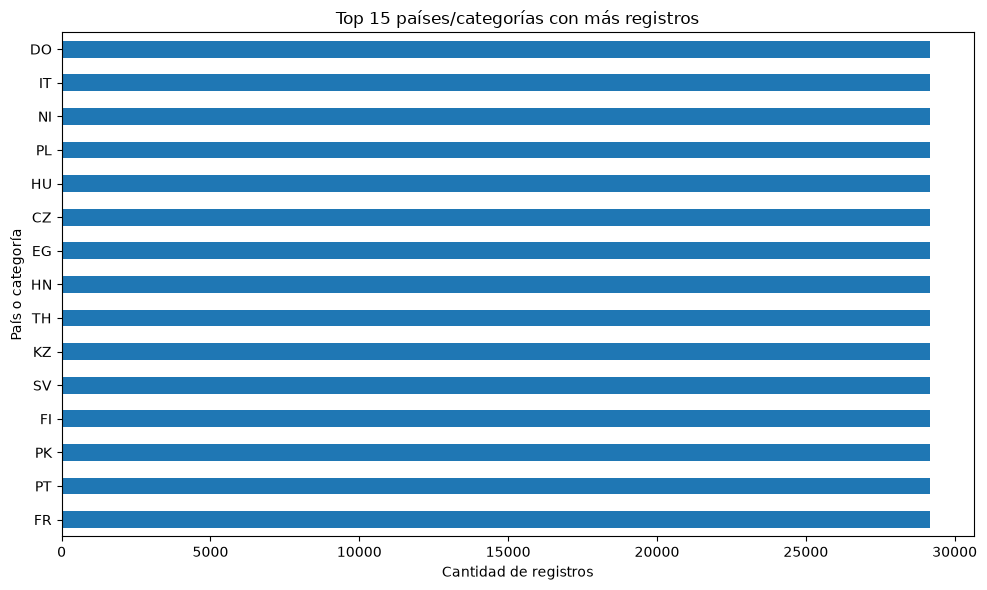

In [25]:
import matplotlib.pyplot as plt

conteo_paises = df_clean["country_clean"].value_counts().head(15)

plt.figure(figsize=(10, 6))
conteo_paises.sort_values().plot(kind="barh")
plt.title("Top 15 países/categorías con más registros")
plt.xlabel("Cantidad de registros")
plt.ylabel("País o categoría")
plt.tight_layout()
plt.show()

In [26]:
# Top 15 artistas o combinaciones con más apariciones en Chile

top_artistas_chile = chile_clean["artists"].value_counts().head(15)

print(top_artistas_chile)

artists
Cris Mj                                         1808
Bad Bunny                                       1233
KAROL G                                         1071
Feid, ATL Jacob                                  489
Tiago PZK, Ke Personajes                         399
FloyyMenor, Lewis Somes                          394
FloyyMenor, Cris Mj                              392
Katteyes, Kidd Voodoo                            370
Lucky Brown, Mateo on the Beatz                  357
KAROL G, Peso Pluma                              354
Myke Towers                                      340
Jimin                                            321
Plan B                                           318
Lucky Brown, Big Cvyu                            311
Jere Klein, Nickoog Clk, Lucky Brown, El BAI     308
Name: count, dtype: int64


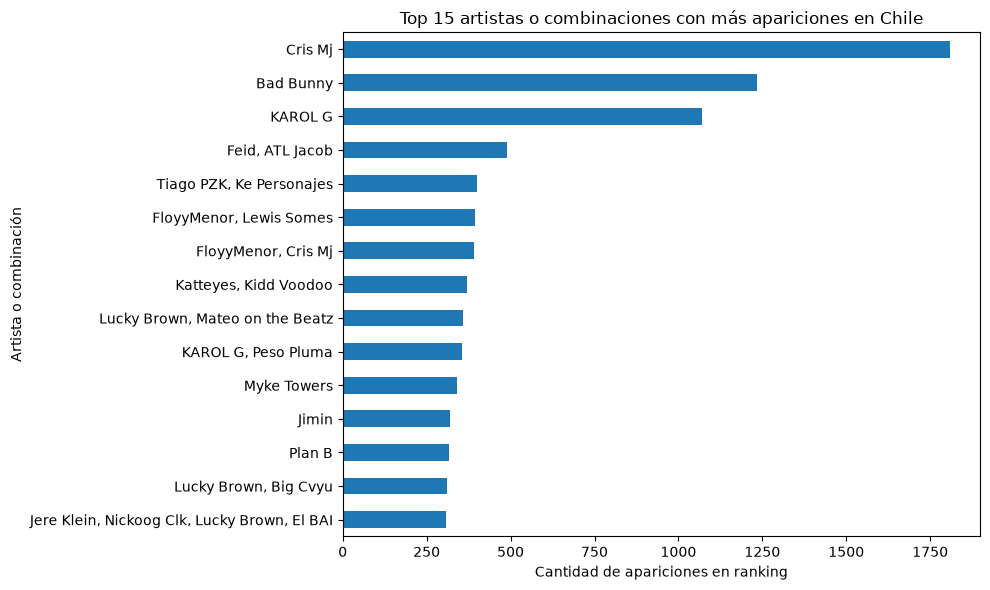

In [27]:
import matplotlib.pyplot as plt

top_artistas_chile = chile_clean["artists"].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_artistas_chile.sort_values().plot(kind="barh")
plt.title("Top 15 artistas o combinaciones con más apariciones en Chile")
plt.xlabel("Cantidad de apariciones en ranking")
plt.ylabel("Artista o combinación")
plt.tight_layout()
plt.show()

In [28]:
# Cantidad de canciones únicas por artista o combinación en Chile

canciones_por_artista_chile = (
    chile_clean
    .groupby("artists")["spotify_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

print(canciones_por_artista_chile)

artists
Bad Bunny                                                24
Cris Mj                                                  16
Kidd Voodoo                                              13
KAROL G                                                   9
LOS 4F, Young Cister, Kidd Voodoo, DrefQuila, Easykid     8
Jere Klein                                                8
Mora                                                      5
Kidd Voodoo, Resonancia Etérea                            5
FloyyMenor, Lewis Somes                                   5
Entremares                                                5
Taylor Swift                                              4
Anuel AA                                                  4
Lucky Brown, Mateo on the Beatz                           4
Maihuen de los Angeles                                    4
Los Bunkers                                               4
Name: spotify_id, dtype: int64


## Análisis de artistas, grupos y colaboraciones

En el dataset original, la columna `artists` no siempre representa a un artista individual. En algunos registros corresponde a un artista único o a un grupo registrado como una sola entidad, mientras que en otros contiene colaboraciones entre dos o más artistas separados por coma.

Por este motivo, se incorporó un análisis específico de colaboraciones mediante las variables `cantidad_artistas` y `es_colaboracion`, con el objetivo de identificar cuántos registros corresponden a una sola entidad artística y cuántos contienen múltiples artistas.

A partir de este análisis se decidió individualizar a los artistas antes de construir la base final de modelamiento. Para ello, las colaboraciones se separan utilizando el delimitador disponible en la columna `artists`, generando una fila independiente para cada artista participante.

De esta forma, una canción colaborativa aporta información al perfil de cada uno de los artistas involucrados. Por ejemplo, una canción registrada como `Juanes, Mon Laferte` contribuye tanto al perfil de Juanes como al perfil de Mon Laferte.

Esta decisión permite que las métricas posteriores representen el desempeño de cada artista individual y evita tratar una colaboración como si constituyera un artista independiente. Sin embargo, se reconoce como limitación que este procedimiento asigna a cada participante la información completa asociada a la canción colaborativa y depende de la estructura textual disponible en el dataset.

In [29]:
# ============================================================
# Análisis exploratorio de artistas, grupos y colaboraciones
# ============================================================

# Esta sección permite explorar la estructura de colaboraciones
# y fundamenta la posterior construcción de la base final
# por artista individualizado.

# Su objetivo es reconocer una limitación metodológica:
# la columna "artists" puede representar un artista individual,
# una banda, un grupo o una combinación de artistas separados por coma.

chile_colaboraciones = chile_clean.copy()

# Crear variable con cantidad de artistas declarados en la columna "artists"
chile_colaboraciones["cantidad_artistas"] = (
    chile_colaboraciones["artists"]
    .fillna("")
    .str.split(",")
    .apply(lambda lista: len([artista.strip() for artista in lista if artista.strip() != ""]))
)

# Crear variable binaria para identificar colaboraciones
chile_colaboraciones["es_colaboracion"] = chile_colaboraciones["cantidad_artistas"] > 1

# Resumen general
print("Registros de Chile analizados:", chile_colaboraciones.shape[0])
print("Registros con artista individual o grupo registrado como único:", (chile_colaboraciones["es_colaboracion"] == False).sum())
print("Registros con colaboración o combinación de artistas:", (chile_colaboraciones["es_colaboracion"] == True).sum())
print("Porcentaje de colaboraciones:", round(chile_colaboraciones["es_colaboracion"].mean() * 100, 2), "%")

# Tabla resumen de artistas individuales/grupos versus colaboraciones
resumen_colaboraciones = (
    chile_colaboraciones
    .groupby("es_colaboracion")
    .agg(
        registros=("name", "count"),
        canciones_unicas=("spotify_id", "nunique"),
        artistas_o_combinaciones=("artists", "nunique"),
        rank_promedio=("daily_rank", "mean"),
        popularidad_promedio=("popularity", "mean")
    )
    .reset_index()
)

resumen_colaboraciones["tipo_registro"] = resumen_colaboraciones["es_colaboracion"].map({
    False: "Artista individual o grupo registrado como único",
    True: "Colaboración o combinación de artistas"
})

resumen_colaboraciones = resumen_colaboraciones[
    [
        "tipo_registro",
        "registros",
        "canciones_unicas",
        "artistas_o_combinaciones",
        "rank_promedio",
        "popularidad_promedio"
    ]
]

resumen_colaboraciones

Registros de Chile analizados: 29103
Registros con artista individual o grupo registrado como único: 9004
Registros con colaboración o combinación de artistas: 20099
Porcentaje de colaboraciones: 69.06 %


,tipo_registro,registros,canciones_unicas,artistas_o_combinaciones,rank_promedio,popularidad_promedio
0,Artista individual o grupo registrado como único,9004,262,113,25.989338,81.497557
1,Colaboración o combinación de artistas,20099,340,295,25.278372,76.676601


In [30]:
# ============================================================
# Base exploratoria por artista individualizado
# ============================================================

# En esta base se separan los artistas por coma.
# Cada artista participante queda en una fila independiente.
# Esta transformación permite verificar el efecto de separar colaboraciones
# y sirve como antecedente para la construcción posterior de la base final
# de modelamiento por artista individual.

chile_individual = chile_colaboraciones.copy()

chile_individual["artist_solo"] = (
    chile_individual["artists"]
    .fillna("")
    .str.split(",")
)

chile_individual = chile_individual.explode("artist_solo")

chile_individual["artist_solo"] = chile_individual["artist_solo"].str.strip()

chile_individual = chile_individual[chile_individual["artist_solo"] != ""]

artistas_individuales = (
    chile_individual
    .groupby("artist_solo")
    .agg(
        apariciones_chile=("daily_rank", "count"),
        canciones_unicas_chile=("spotify_id", "nunique"),
        mejor_rank_chile=("daily_rank", "min"),
        peor_rank_chile=("daily_rank", "max"),
        rank_promedio_chile=("daily_rank", "mean"),
        popularidad_promedio=("popularity", "mean"),
        movimiento_diario_promedio=("daily_movement", "mean"),
        movimiento_semanal_promedio=("weekly_movement", "mean"),
        permanencia_dias=("snapshot_date", "nunique")
    )
    .reset_index()
)

artistas_individuales["puntaje_posicion_chile"] = 51 - artistas_individuales["mejor_rank_chile"]

artistas_individuales = artistas_individuales.sort_values(
    by="apariciones_chile",
    ascending=False
)

print("Artistas o combinaciones en la base original:", chile_clean["artists"].nunique())
print("Artistas individualizados después de separar colaboraciones:", artistas_individuales["artist_solo"].nunique())

artistas_individuales.head(15)

Artistas o combinaciones en la base original: 408
Artistas individualizados después de separar colaboraciones: 351


,artist_solo,apariciones_chile,canciones_unicas_chile,mejor_rank_chile,peor_rank_chile,rank_promedio_chile,popularidad_promedio,movimiento_diario_promedio,movimiento_semanal_promedio,permanencia_dias,puntaje_posicion_chile
61,Cris Mj,3797,44,1,50,22.263366,75.865157,0.507769,1.686068,580,50
128,Jere Klein,3792,45,1,50,21.359705,71.833070,0.527954,1.733122,581,50
156,Kidd Voodoo,2937,57,1,50,22.418114,68.628873,0.653047,2.576098,519,50
199,Lucky Brown,2471,27,1,50,21.342776,71.047754,0.588021,2.173209,582,50
28,Bad Bunny,2127,39,1,50,19.866008,90.420310,0.356370,2.083216,486,50
145,KAROL G,1643,17,1,50,31.343274,88.007912,0.265368,0.983567,582,50
214,Mateo on the Beatz,1542,18,1,50,20.853437,70.036316,0.599870,1.986381,582,50
99,FloyyMenor,1482,20,1,50,20.821862,77.576923,0.701754,3.002024,433,50
98,Feid,1112,14,2,50,25.379496,88.690647,0.430755,1.288669,542,49
256,Pablo Chill-E,1055,16,1,50,25.905213,70.353555,0.433175,1.288152,530,50


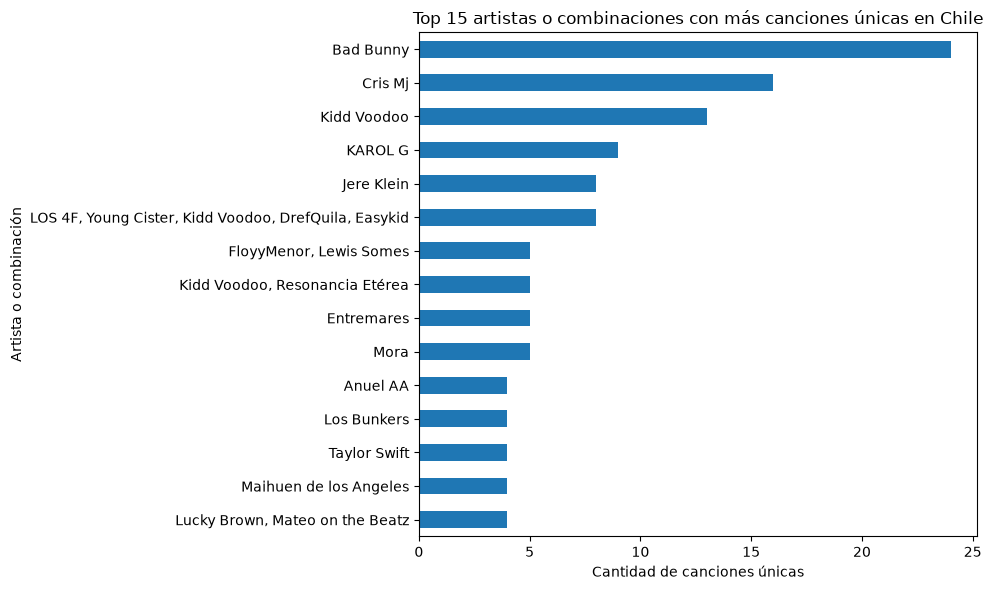

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
canciones_por_artista_chile.sort_values().plot(kind="barh")
plt.title("Top 15 artistas o combinaciones con más canciones únicas en Chile")
plt.xlabel("Cantidad de canciones únicas")
plt.ylabel("Artista o combinación")
plt.tight_layout()
plt.show()

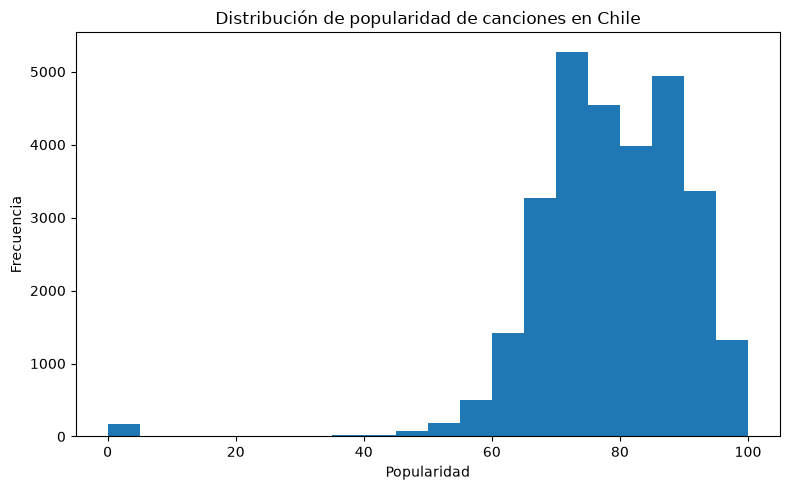

In [32]:
plt.figure(figsize=(8, 5))
chile_clean["popularity"].plot(kind="hist", bins=20)
plt.title("Distribución de popularidad de canciones en Chile")
plt.xlabel("Popularidad")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

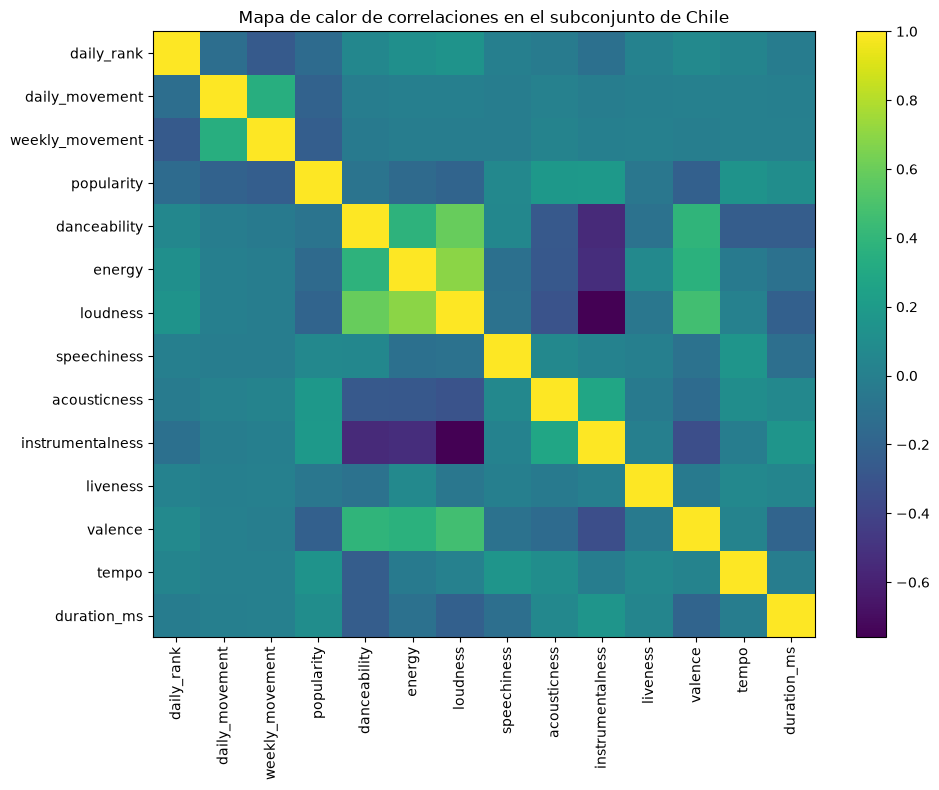

In [33]:
import matplotlib.pyplot as plt

cols_corr = [
    "daily_rank", "daily_movement", "weekly_movement", "popularity",
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "duration_ms"
]

corr = chile_clean[cols_corr].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(cols_corr)), cols_corr, rotation=90)
plt.yticks(range(len(cols_corr)), cols_corr)
plt.title("Mapa de calor de correlaciones en el subconjunto de Chile")
plt.tight_layout()
plt.show()

## Construcción de base agregada por artista individual

En esta etapa se transforma el dataset desde el nivel original de canción presente en un ranking diario hacia una base agregada por artista individual. Esta transformación es necesaria porque el objetivo del proyecto es caracterizar el desempeño de los artistas y no tratar las colaboraciones como entidades independientes.

Antes de realizar la agregación, la columna `artists` se separa utilizando la coma como delimitador y posteriormente se aplica una expansión de registros mediante `explode()`. De esta forma, cada artista participante en una canción colaborativa queda representado individualmente.

La información correspondiente a una colaboración se atribuye a cada uno de los artistas participantes. Por lo tanto, las apariciones en ranking, canciones, posiciones, popularidad y demás métricas de una canción colaborativa contribuyen al perfil individual de cada artista involucrado.

Posteriormente, los registros se agrupan por artista individual y se calculan métricas de apariciones en rankings de Chile, cantidad de canciones únicas, mejor y peor posición alcanzada, ranking promedio, popularidad promedio, movimiento diario y semanal, permanencia en días y puntaje de posición local.

Como resultado de este proceso se obtuvo una base final de 351 artistas individualizados, que constituye la unidad de análisis utilizada en las etapas posteriores de PCA, K-Means y modelamiento supervisado.

In [34]:
# ============================================================
# Construcción de base agregada por ARTISTA INDIVIDUAL en Chile
# ============================================================

chile_artistas = chile_clean.copy()

# Asegurar formato de fecha
chile_artistas["snapshot_date"] = pd.to_datetime(
    chile_artistas["snapshot_date"],
    errors="coerce"
)

# ------------------------------------------------------------
# Separar colaboraciones
# Cada artista participante recibe la aparición de la canción
# ------------------------------------------------------------

chile_artistas["artists"] = (
    chile_artistas["artists"]
    .fillna("")
    .str.split(",")
)

# Una fila por cada artista participante
chile_artistas = chile_artistas.explode("artists")

# Limpiar espacios
chile_artistas["artists"] = chile_artistas["artists"].str.strip()

# Eliminar valores vacíos
chile_artistas = chile_artistas[
    chile_artistas["artists"] != ""
].copy()

# ------------------------------------------------------------
# Construir base agregada por artista individual
# ------------------------------------------------------------

base_artistas_chile = (
    chile_artistas
    .groupby("artists")
    .agg(
        apariciones_chile=("daily_rank", "count"),

        # Spotify ID es más seguro que el nombre para identificar canciones únicas
        canciones_unicas_chile=("spotify_id", "nunique"),

        mejor_rank_chile=("daily_rank", "min"),
        peor_rank_chile=("daily_rank", "max"),
        rank_promedio_chile=("daily_rank", "mean"),
        popularidad_promedio=("popularity", "mean"),
        movimiento_diario_promedio=("daily_movement", "mean"),
        movimiento_semanal_promedio=("weekly_movement", "mean"),
        primer_dia_ranking=("snapshot_date", "min"),
        ultimo_dia_ranking=("snapshot_date", "max"),
        permanencia_dias=("snapshot_date", "nunique")
    )
    .reset_index()
)

# Mejor posición -> mayor puntaje
base_artistas_chile["puntaje_posicion_chile"] = (
    51 - base_artistas_chile["mejor_rank_chile"]
)

# Ordenar por apariciones
base_artistas_chile = base_artistas_chile.sort_values(
    by="apariciones_chile",
    ascending=False
)

print("Cantidad de artistas individualizados:", base_artistas_chile["artists"].nunique())
print("Tamaño de la base agregada:", base_artistas_chile.shape)

base_artistas_chile.head(15)

Cantidad de artistas individualizados: 351
Tamaño de la base agregada: (351, 13)


,artists,apariciones_chile,canciones_unicas_chile,mejor_rank_chile,peor_rank_chile,rank_promedio_chile,popularidad_promedio,movimiento_diario_promedio,movimiento_semanal_promedio,primer_dia_ranking,ultimo_dia_ranking,permanencia_dias,puntaje_posicion_chile
61,Cris Mj,3797,44,1,50,22.263366,75.865157,0.507769,1.686068,2023-10-18,2025-06-11,580,50
128,Jere Klein,3792,45,1,50,21.359705,71.833070,0.527954,1.733122,2023-10-18,2025-06-11,581,50
156,Kidd Voodoo,2937,57,1,50,22.418114,68.628873,0.653047,2.576098,2023-10-18,2025-06-11,519,50
199,Lucky Brown,2471,27,1,50,21.342776,71.047754,0.588021,2.173209,2023-10-18,2025-06-11,582,50
28,Bad Bunny,2127,39,1,50,19.866008,90.420310,0.356370,2.083216,2023-10-18,2025-06-11,486,50
145,KAROL G,1643,17,1,50,31.343274,88.007912,0.265368,0.983567,2023-10-18,2025-06-11,582,50
214,Mateo on the Beatz,1542,18,1,50,20.853437,70.036316,0.599870,1.986381,2023-10-18,2025-06-11,582,50
99,FloyyMenor,1482,20,1,50,20.821862,77.576923,0.701754,3.002024,2024-01-07,2025-05-05,433,50
98,Feid,1112,14,2,50,25.379496,88.690647,0.430755,1.288669,2023-10-18,2025-05-11,542,49
256,Pablo Chill-E,1055,16,1,50,25.905213,70.353555,0.433175,1.288152,2023-10-18,2025-06-07,530,50


## Selección y escalamiento de variables para modelamiento

Luego de construir la base agregada por artista, se seleccionaron variables numéricas relacionadas con presencia, permanencia, posición, popularidad, movimiento y diversidad de repertorio. Estas variables serán utilizadas como entrada para PCA y K-Means.

Antes de modelar, las variables se escalan mediante `StandardScaler`, ya que presentan rangos distintos. Este paso evita que variables con valores más grandes, como la cantidad de apariciones en ranking, dominen el cálculo de distancias utilizado por K-Means.

In [35]:
# Selección de variables para PCA y K-Means

from sklearn.preprocessing import StandardScaler

variables_modelo = [
    "apariciones_chile",
    "canciones_unicas_chile",
    "rank_promedio_chile",
    "popularidad_promedio",
    "movimiento_diario_promedio",
    "movimiento_semanal_promedio",
    "permanencia_dias",
    "puntaje_posicion_chile"
]

# Crear base solo con artistas y variables seleccionadas
base_modelo_artistas = base_artistas_chile[["artists"] + variables_modelo].copy()

# Revisar valores nulos en las variables seleccionadas
print("Valores nulos por variable:")
print(base_modelo_artistas[variables_modelo].isna().sum())

# En caso de existir valores nulos, se reemplazan por la mediana de cada variable
base_modelo_artistas[variables_modelo] = base_modelo_artistas[variables_modelo].fillna(
    base_modelo_artistas[variables_modelo].median()
)

# Escalamiento de variables numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(base_modelo_artistas[variables_modelo])

print("Tamaño de la matriz escalada:", X_scaled.shape)

base_modelo_artistas.head(10)

Valores nulos por variable:
apariciones_chile              0
canciones_unicas_chile         0
rank_promedio_chile            0
popularidad_promedio           0
movimiento_diario_promedio     0
movimiento_semanal_promedio    0
permanencia_dias               0
puntaje_posicion_chile         0
dtype: int64
Tamaño de la matriz escalada: (351, 8)


,artists,apariciones_chile,canciones_unicas_chile,rank_promedio_chile,popularidad_promedio,movimiento_diario_promedio,movimiento_semanal_promedio,permanencia_dias,puntaje_posicion_chile
61,Cris Mj,3797,44,22.263366,75.865157,0.507769,1.686068,580,50
128,Jere Klein,3792,45,21.359705,71.833070,0.527954,1.733122,581,50
156,Kidd Voodoo,2937,57,22.418114,68.628873,0.653047,2.576098,519,50
199,Lucky Brown,2471,27,21.342776,71.047754,0.588021,2.173209,582,50
28,Bad Bunny,2127,39,19.866008,90.420310,0.356370,2.083216,486,50
145,KAROL G,1643,17,31.343274,88.007912,0.265368,0.983567,582,50
214,Mateo on the Beatz,1542,18,20.853437,70.036316,0.599870,1.986381,582,50
99,FloyyMenor,1482,20,20.821862,77.576923,0.701754,3.002024,433,50
98,Feid,1112,14,25.379496,88.690647,0.430755,1.288669,542,49
256,Pablo Chill-E,1055,16,25.905213,70.353555,0.433175,1.288152,530,50


## Aplicación inicial de PCA

En esta etapa se aplica Análisis de Componentes Principales (PCA) sobre la matriz escalada de variables por artista. El objetivo es reducir la dimensionalidad de los datos y observar cuánta varianza explica cada componente principal.

Este paso permite preparar los datos para técnicas de agrupamiento como K-Means y facilita la visualización de perfiles de artistas en menos dimensiones.

  Componente  Varianza explicada  Varianza acumulada
0        PC1            0.425672            0.425672
1        PC2            0.276416            0.702088
2        PC3            0.156411            0.858499
3        PC4            0.082164            0.940663
4        PC5            0.029373            0.970036
5        PC6            0.012620            0.982656
6        PC7            0.011070            0.993726
7        PC8            0.006274            1.000000


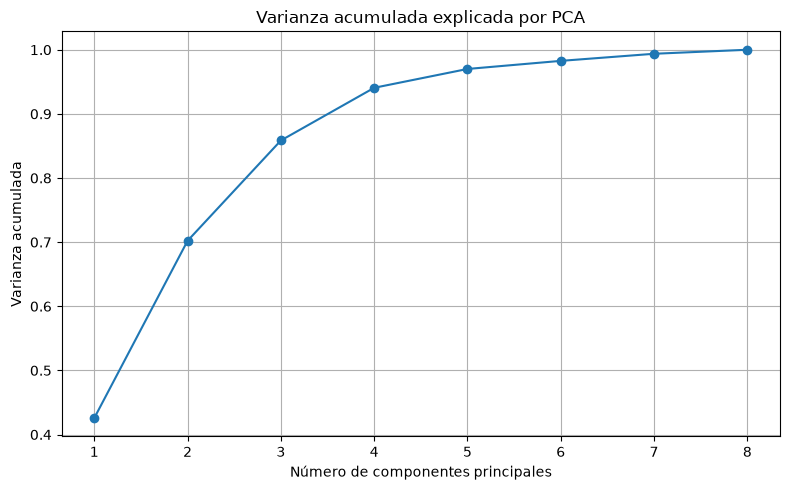

In [36]:
# Aplicación inicial de PCA

from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

# Aplicar PCA sobre la matriz escalada
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calcular varianza explicada por componente
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = varianza_explicada.cumsum()

# Crear tabla resumen
tabla_pca = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(varianza_explicada))],
    "Varianza explicada": varianza_explicada,
    "Varianza acumulada": varianza_acumulada
})

print(tabla_pca)

# Gráfico de varianza acumulada
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker="o")
plt.title("Varianza acumulada explicada por PCA")
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza acumulada")
plt.xticks(range(1, len(varianza_acumulada) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

## Selección de componentes principales para K-Means

A partir del análisis de varianza explicada acumulada, se seleccionaron cuatro componentes principales para continuar con el proceso de agrupamiento.

Los cuatro primeros componentes explican aproximadamente el 94,07 % de la variabilidad total contenida en las ocho variables originales utilizadas para caracterizar a los artistas. Este porcentaje permite conservar la mayor parte de la información del conjunto de datos y, al mismo tiempo, reducir la dimensionalidad antes de aplicar K-Means.

La matriz resultante queda compuesta por 351 artistas individualizados y cuatro componentes principales. Estos componentes serán utilizados como entrada para el proceso de clustering, disminuyendo la redundancia entre variables y facilitando la identificación de perfiles de comportamiento similares.

In [37]:
# Crear matriz PCA final con 4 componentes principales

pca_final = PCA(n_components=4)
X_pca_4 = pca_final.fit_transform(X_scaled)

# Crear DataFrame con los componentes principales
pca_artistas = pd.DataFrame(
    X_pca_4,
    columns=["PC1", "PC2", "PC3", "PC4"]
)

# Agregar nombre de artista individualizado
pca_artistas["artists"] = base_modelo_artistas["artists"].values

print("Tamaño de la matriz PCA final:", X_pca_4.shape)
print("Varianza acumulada con 4 componentes:", pca_final.explained_variance_ratio_.sum())

pca_artistas.head(10)

Tamaño de la matriz PCA final: (351, 4)
Varianza acumulada con 4 componentes: 0.9406633629035184


,PC1,PC2,PC3,PC4,artists
0,9.802185,-0.050895,-6.020348,2.147827,Cris Mj
1,9.855241,0.016712,-6.191886,2.000349,Jere Klein
2,9.457051,0.134771,-6.460977,2.039123,Kidd Voodoo
3,7.064262,0.078037,-3.437931,0.696405,Lucky Brown
4,7.464611,0.117786,-3.437163,1.776382,Bad Bunny
5,5.323363,-0.567894,-1.562866,0.849789,KAROL G
6,5.385021,0.116648,-1.793646,-0.125756,Mateo on the Beatz
7,4.972647,0.231779,-1.649990,0.363127,FloyyMenor
8,4.523947,-0.235702,-0.618934,0.418446,Feid
9,4.368894,-0.150355,-1.256389,-0.249604,Pablo Chill-E


## Evaluación preliminar del número de clusters

Una vez reducida la dimensionalidad mediante PCA, se evalúa el número de clusters para K-Means. Para esto se prueban distintos valores de `k` y se comparan métricas internas de clustering: Silhouette Score, Davies-Bouldin Index y Calinski-Harabasz Index.

Estas métricas permiten analizar si los grupos formados son compactos y están bien separados. Sin embargo, la elección final del número de clusters también debe considerar la interpretación de los perfiles de artistas y la coherencia con el objetivo del proyecto.

In [38]:
# Evaluación de número de clusters para K-Means

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd
import matplotlib.pyplot as plt

resultados_kmeans = []

# Probar distintos valores de k
for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_pca_4)
    
    silhouette = silhouette_score(X_pca_4, labels)
    davies_bouldin = davies_bouldin_score(X_pca_4, labels)
    calinski_harabasz = calinski_harabasz_score(X_pca_4, labels)
    
    resultados_kmeans.append({
        "k": k,
        "Silhouette Score": silhouette,
        "Davies-Bouldin Index": davies_bouldin,
        "Calinski-Harabasz Index": calinski_harabasz
    })

tabla_kmeans = pd.DataFrame(resultados_kmeans)

tabla_kmeans

,k,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,2,0.324387,1.267022,134.073822
1,3,0.381781,0.944659,164.176393
2,4,0.411200,0.785128,227.640414
3,5,0.364917,0.788256,222.522695
4,6,0.377256,0.771551,231.523038
5,7,0.397847,0.784203,246.806982
6,8,0.347997,0.844969,247.495410


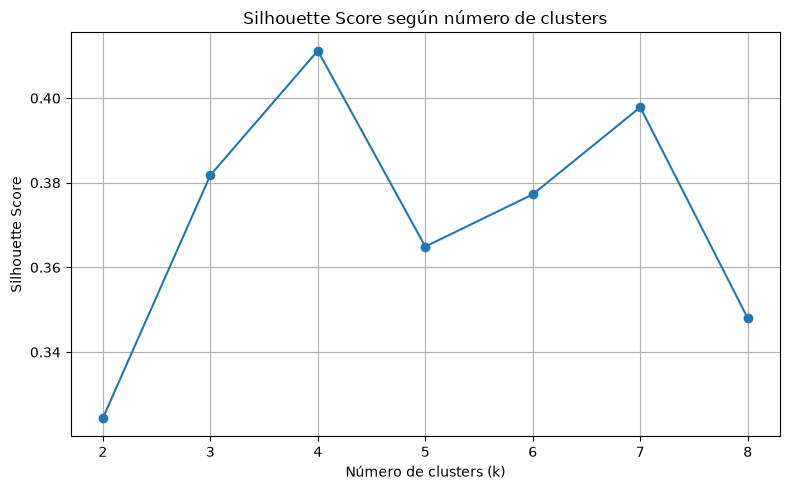

In [39]:
# Gráfico de Silhouette Score

plt.figure(figsize=(8, 5))
plt.plot(tabla_kmeans["k"], tabla_kmeans["Silhouette Score"], marker="o")
plt.title("Silhouette Score según número de clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(tabla_kmeans["k"])
plt.grid(True)
plt.tight_layout()
plt.show()

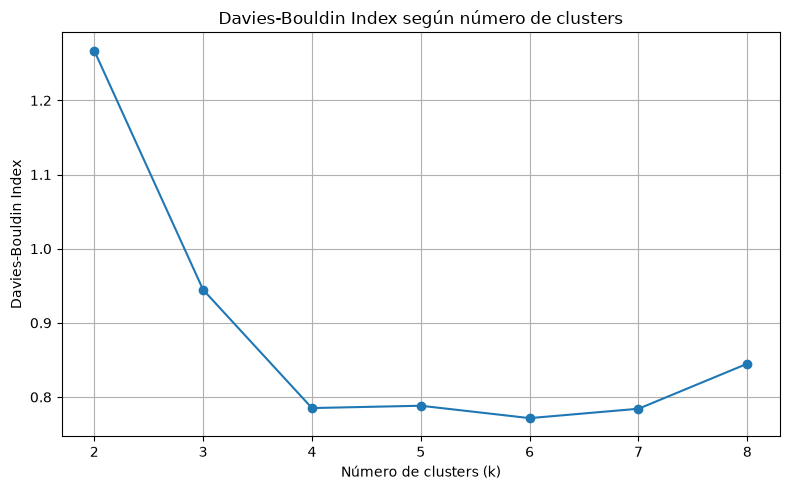

In [40]:
# Gráfico de Davies-Bouldin Index

plt.figure(figsize=(8, 5))
plt.plot(tabla_kmeans["k"], tabla_kmeans["Davies-Bouldin Index"], marker="o")
plt.title("Davies-Bouldin Index según número de clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Davies-Bouldin Index")
plt.xticks(tabla_kmeans["k"])
plt.grid(True)
plt.tight_layout()
plt.show()

## Aplicación inicial de K-Means con cuatro clusters

Para determinar el número de clusters más adecuado se evaluaron valores de `k` entre 2 y 8 utilizando tres métricas internas de clustering: Silhouette Score, Davies-Bouldin Index y Calinski-Harabasz Index.

Los resultados mostraron que `k = 4` obtuvo el mayor Silhouette Score, con un valor aproximado de 0,4112. Este resultado indica una combinación favorable entre cohesión interna de los grupos y separación entre clusters. Aunque otros valores de `k` presentan resultados competitivos en las métricas Davies-Bouldin y Calinski-Harabasz, cuatro clusters ofrecen un equilibrio adecuado entre desempeño cuantitativo e interpretabilidad.

Por esta razón, se selecciona `k = 4` para la aplicación final de K-Means. El objetivo es asignar cada artista individualizado a un perfil preliminar según su comportamiento en los rankings de Spotify Chile y las métricas agregadas construidas previamente.

Con esta configuración, los 351 artistas individualizados se distribuyen en cuatro grupos de 157, 47, 8 y 139 artistas, respectivamente. La interpretación definitiva de cada cluster se realiza posteriormente mediante el análisis de sus características promedio.

In [41]:
# Aplicación final de K-Means con k = 4

k_optimo = 4

kmeans_final = KMeans(
    n_clusters=k_optimo,
    random_state=42,
    n_init=10
)

# Asignar cluster a cada artista
clusters = kmeans_final.fit_predict(X_pca_4)

# Agregar cluster a las bases de trabajo
base_modelo_artistas["cluster"] = clusters
pca_artistas["cluster"] = clusters

# Ver cantidad de artistas por cluster
conteo_clusters = base_modelo_artistas["cluster"].value_counts().sort_index()

print("Cantidad de artistas por cluster:")
print(conteo_clusters)

base_modelo_artistas.head(10)

Cantidad de artistas por cluster:
cluster
0    157
1     47
2      8
3    139
Name: count, dtype: int64


,artists,apariciones_chile,canciones_unicas_chile,rank_promedio_chile,popularidad_promedio,movimiento_diario_promedio,movimiento_semanal_promedio,permanencia_dias,puntaje_posicion_chile,cluster
61,Cris Mj,3797,44,22.263366,75.865157,0.507769,1.686068,580,50,2
128,Jere Klein,3792,45,21.359705,71.833070,0.527954,1.733122,581,50,2
156,Kidd Voodoo,2937,57,22.418114,68.628873,0.653047,2.576098,519,50,2
199,Lucky Brown,2471,27,21.342776,71.047754,0.588021,2.173209,582,50,2
28,Bad Bunny,2127,39,19.866008,90.420310,0.356370,2.083216,486,50,2
145,KAROL G,1643,17,31.343274,88.007912,0.265368,0.983567,582,50,2
214,Mateo on the Beatz,1542,18,20.853437,70.036316,0.599870,1.986381,582,50,2
99,FloyyMenor,1482,20,20.821862,77.576923,0.701754,3.002024,433,50,2
98,Feid,1112,14,25.379496,88.690647,0.430755,1.288669,542,49,0
256,Pablo Chill-E,1055,16,25.905213,70.353555,0.433175,1.288152,530,50,0


## Caracterización inicial de los clusters

Luego de aplicar K-Means con cuatro clusters, se analizan las variables promedio de cada grupo. Este paso permite interpretar qué tipo de artistas reúne cada cluster, considerando métricas como apariciones en rankings de Chile, canciones únicas, posición promedio, popularidad, movimiento y permanencia.

La interpretación de clusters es necesaria porque K-Means solo asigna números de grupo, pero no entrega automáticamente un significado para cada perfil.

In [42]:
# Caracterización de clusters mediante promedios de variables

# Calcular promedios por cluster
resumen_clusters = (
    base_modelo_artistas
    .groupby("cluster")[variables_modelo]
    .mean()
    .round(2)
)

# Agregar cantidad de artistas por cluster
conteo_clusters = base_modelo_artistas["cluster"].value_counts().sort_index()
resumen_clusters.insert(0, "cantidad_artistas", conteo_clusters)

resumen_clusters

,cantidad_artistas,apariciones_chile,canciones_unicas_chile,rank_promedio_chile,popularidad_promedio,movimiento_diario_promedio,movimiento_semanal_promedio,permanencia_dias,puntaje_posicion_chile
cluster,,,,,,,,,
0,157,232.17,3.76,26.64,77.41,0.54,2.40,177.61,43.76
1,47,3.66,1.74,24.95,61.42,19.33,25.05,2.79,34.34
2,8,2473.88,33.38,22.53,76.68,0.53,2.03,543.12,50.00
3,139,20.27,1.54,42.05,63.76,2.23,4.65,19.51,17.32


In [43]:
# Mostrar el resumen completo de clusters en formato vertical
resumen_clusters.T

cluster,0,1,2,3
cantidad_artistas,157.00,47.00,8.00,139.00
apariciones_chile,232.17,3.66,2473.88,20.27
canciones_unicas_chile,3.76,1.74,33.38,1.54
rank_promedio_chile,26.64,24.95,22.53,42.05
popularidad_promedio,77.41,61.42,76.68,63.76
movimiento_diario_promedio,0.54,19.33,0.53,2.23
movimiento_semanal_promedio,2.40,25.05,2.03,4.65
permanencia_dias,177.61,2.79,543.12,19.51
puntaje_posicion_chile,43.76,34.34,50.00,17.32


In [44]:
# Ver principales artistas de cada cluster según apariciones en Chile

from IPython.display import display

columnas_revision = [
    "artists",
    "cluster",
    "apariciones_chile",
    "canciones_unicas_chile",
    "rank_promedio_chile",
    "popularidad_promedio",
    "permanencia_dias",
    "puntaje_posicion_chile"
]

for cluster_id in sorted(base_modelo_artistas["cluster"].unique()):
    print(f"\nCluster {cluster_id}")
    
    muestra_cluster = (
        base_modelo_artistas[base_modelo_artistas["cluster"] == cluster_id]
        .sort_values(by="apariciones_chile", ascending=False)
        [columnas_revision]
        .head(10)
    )
    
    display(muestra_cluster)


Cluster 0


,artists,cluster,apariciones_chile,canciones_unicas_chile,rank_promedio_chile,popularidad_promedio,permanencia_dias,puntaje_posicion_chile
98,Feid,0,1112,14,25.379496,88.690647,542,49
256,Pablo Chill-E,0,1055,16,25.905213,70.353555,530,50
253,Ovy On The Drums,0,856,10,20.571262,81.779206,329,50
242,Nickoog Clk,0,798,9,27.199248,72.437343,421,50
305,Swift 047,0,796,10,20.746231,71.820352,342,50
277,Rauw Alejandro,0,737,5,26.385346,86.595658,526,48
83,DrefQuila,0,723,16,25.038728,67.467497,311,50
127,Jairo Vera,0,718,15,22.640669,71.402507,393,50
151,Ke Personajes,0,699,5,24.133047,80.959943,524,47
230,Myke Towers,0,590,8,25.733898,88.391525,436,48



Cluster 1


,artists,cluster,apariciones_chile,canciones_unicas_chile,rank_promedio_chile,popularidad_promedio,permanencia_dias,puntaje_posicion_chile
187,Los Hermanos Campos,1,10,3,22.600000,59.300000,4,46
200,Luis Miguel,1,9,4,30.111111,71.888889,4,42
326,Villano Antillano,1,9,1,32.000000,84.111111,9,32
173,La Sonora De Tommy Rey,1,8,4,12.000000,40.875000,2,46
212,Mariah Carey,1,6,2,16.333333,94.666667,4,50
302,Sonora Palacios,1,6,3,9.500000,49.500000,2,48
18,Arcane,1,5,2,35.000000,84.800000,5,34
304,Stromae,1,5,2,35.000000,84.800000,5,34
268,Pomme,1,5,2,35.000000,84.800000,5,34
121,Hugo Lagos,1,5,4,31.000000,55.400000,2,39



Cluster 2


,artists,cluster,apariciones_chile,canciones_unicas_chile,rank_promedio_chile,popularidad_promedio,permanencia_dias,puntaje_posicion_chile
61,Cris Mj,2,3797,44,22.263366,75.865157,580,50
128,Jere Klein,2,3792,45,21.359705,71.833070,581,50
156,Kidd Voodoo,2,2937,57,22.418114,68.628873,519,50
199,Lucky Brown,2,2471,27,21.342776,71.047754,582,50
28,Bad Bunny,2,2127,39,19.866008,90.420310,486,50
145,KAROL G,2,1643,17,31.343274,88.007912,582,50
214,Mateo on the Beatz,2,1542,18,20.853437,70.036316,582,50
99,FloyyMenor,2,1482,20,20.821862,77.576923,433,50



Cluster 3


,artists,cluster,apariciones_chile,canciones_unicas_chile,rank_promedio_chile,popularidad_promedio,permanencia_dias,puntaje_posicion_chile
195,Los Ángeles Azules,3,207,2,39.869565,80.560386,207,23
64,DJ Luian,3,125,2,37.736000,84.656000,125,26
207,Mambo Kingz,3,125,2,37.736000,84.656000,125,26
290,Sabrina Carpenter,3,89,3,40.764045,95.528090,50,28
10,Almighty,3,83,2,34.759036,68.313253,83,33
147,Kail BRL,3,82,1,43.000000,66.195122,82,17
211,Maria Becerra,3,79,3,39.025316,72.468354,79,24
318,Tokischa,3,76,2,39.184211,88.644737,76,32
37,Billie Eilish,3,74,3,45.648649,97.459459,72,14
287,Ryan Castro,3,73,3,39.219178,78.191781,73,33


In [45]:
# Mostrar resumen de clusters en formato más fácil de leer

pd.set_option("display.max_columns", None)

resumen_clusters.T

cluster,0,1,2,3
cantidad_artistas,157.00,47.00,8.00,139.00
apariciones_chile,232.17,3.66,2473.88,20.27
canciones_unicas_chile,3.76,1.74,33.38,1.54
rank_promedio_chile,26.64,24.95,22.53,42.05
popularidad_promedio,77.41,61.42,76.68,63.76
movimiento_diario_promedio,0.54,19.33,0.53,2.23
movimiento_semanal_promedio,2.40,25.05,2.03,4.65
permanencia_dias,177.61,2.79,543.12,19.51
puntaje_posicion_chile,43.76,34.34,50.00,17.32


In [46]:
# Revisar todos los artistas del cluster 2

base_modelo_artistas[
    base_modelo_artistas["cluster"] == 2
][[
    "artists",
    "cluster",
    "apariciones_chile",
    "canciones_unicas_chile",
    "rank_promedio_chile",
    "popularidad_promedio",
    "permanencia_dias",
    "puntaje_posicion_chile"
]].sort_values(by="apariciones_chile", ascending=False)

,artists,cluster,apariciones_chile,canciones_unicas_chile,rank_promedio_chile,popularidad_promedio,permanencia_dias,puntaje_posicion_chile
61,Cris Mj,2,3797,44,22.263366,75.865157,580,50
128,Jere Klein,2,3792,45,21.359705,71.833070,581,50
156,Kidd Voodoo,2,2937,57,22.418114,68.628873,519,50
199,Lucky Brown,2,2471,27,21.342776,71.047754,582,50
28,Bad Bunny,2,2127,39,19.866008,90.420310,486,50
145,KAROL G,2,1643,17,31.343274,88.007912,582,50
214,Mateo on the Beatz,2,1542,18,20.853437,70.036316,582,50
99,FloyyMenor,2,1482,20,20.821862,77.576923,433,50


In [47]:
# Principales artistas por cluster según apariciones en Chile

columnas_revision = [
    "artists",
    "cluster",
    "apariciones_chile",
    "canciones_unicas_chile",
    "rank_promedio_chile",
    "popularidad_promedio",
    "permanencia_dias",
    "puntaje_posicion_chile"
]

for cluster_id in sorted(base_modelo_artistas["cluster"].unique()):
    print(f"\n===== Cluster {cluster_id} =====")
    
    muestra_cluster = (
        base_modelo_artistas[base_modelo_artistas["cluster"] == cluster_id]
        .sort_values(by="apariciones_chile", ascending=False)
        [columnas_revision]
        .head(10)
    )
    
    display(muestra_cluster)


===== Cluster 0 =====


,artists,cluster,apariciones_chile,canciones_unicas_chile,rank_promedio_chile,popularidad_promedio,permanencia_dias,puntaje_posicion_chile
98,Feid,0,1112,14,25.379496,88.690647,542,49
256,Pablo Chill-E,0,1055,16,25.905213,70.353555,530,50
253,Ovy On The Drums,0,856,10,20.571262,81.779206,329,50
242,Nickoog Clk,0,798,9,27.199248,72.437343,421,50
305,Swift 047,0,796,10,20.746231,71.820352,342,50
277,Rauw Alejandro,0,737,5,26.385346,86.595658,526,48
83,DrefQuila,0,723,16,25.038728,67.467497,311,50
127,Jairo Vera,0,718,15,22.640669,71.402507,393,50
151,Ke Personajes,0,699,5,24.133047,80.959943,524,47
230,Myke Towers,0,590,8,25.733898,88.391525,436,48



===== Cluster 1 =====


,artists,cluster,apariciones_chile,canciones_unicas_chile,rank_promedio_chile,popularidad_promedio,permanencia_dias,puntaje_posicion_chile
187,Los Hermanos Campos,1,10,3,22.600000,59.300000,4,46
200,Luis Miguel,1,9,4,30.111111,71.888889,4,42
326,Villano Antillano,1,9,1,32.000000,84.111111,9,32
173,La Sonora De Tommy Rey,1,8,4,12.000000,40.875000,2,46
212,Mariah Carey,1,6,2,16.333333,94.666667,4,50
302,Sonora Palacios,1,6,3,9.500000,49.500000,2,48
18,Arcane,1,5,2,35.000000,84.800000,5,34
304,Stromae,1,5,2,35.000000,84.800000,5,34
268,Pomme,1,5,2,35.000000,84.800000,5,34
121,Hugo Lagos,1,5,4,31.000000,55.400000,2,39



===== Cluster 2 =====


,artists,cluster,apariciones_chile,canciones_unicas_chile,rank_promedio_chile,popularidad_promedio,permanencia_dias,puntaje_posicion_chile
61,Cris Mj,2,3797,44,22.263366,75.865157,580,50
128,Jere Klein,2,3792,45,21.359705,71.833070,581,50
156,Kidd Voodoo,2,2937,57,22.418114,68.628873,519,50
199,Lucky Brown,2,2471,27,21.342776,71.047754,582,50
28,Bad Bunny,2,2127,39,19.866008,90.420310,486,50
145,KAROL G,2,1643,17,31.343274,88.007912,582,50
214,Mateo on the Beatz,2,1542,18,20.853437,70.036316,582,50
99,FloyyMenor,2,1482,20,20.821862,77.576923,433,50



===== Cluster 3 =====


,artists,cluster,apariciones_chile,canciones_unicas_chile,rank_promedio_chile,popularidad_promedio,permanencia_dias,puntaje_posicion_chile
195,Los Ángeles Azules,3,207,2,39.869565,80.560386,207,23
64,DJ Luian,3,125,2,37.736000,84.656000,125,26
207,Mambo Kingz,3,125,2,37.736000,84.656000,125,26
290,Sabrina Carpenter,3,89,3,40.764045,95.528090,50,28
10,Almighty,3,83,2,34.759036,68.313253,83,33
147,Kail BRL,3,82,1,43.000000,66.195122,82,17
211,Maria Becerra,3,79,3,39.025316,72.468354,79,24
318,Tokischa,3,76,2,39.184211,88.644737,76,32
37,Billie Eilish,3,74,3,45.648649,97.459459,72,14
287,Ryan Castro,3,73,3,39.219178,78.191781,73,33


## Asignación preliminar de nombres a los perfiles

A partir del resumen estadístico de cada cluster, se asignan nombres interpretativos preliminares a los perfiles de artistas. Estos nombres no son generados automáticamente por K-Means, sino que se definen a partir de las características promedio de cada grupo, como apariciones en ranking, canciones únicas, popularidad, permanencia y posición promedio.

In [48]:
# Asignar nombres interpretativos a los clusters

nombres_clusters = {
    0: "Presencia sostenida en rankings chilenos",
    1: "Aparición puntual o comportamiento emergente",
    2: "Artistas consolidados de alto desempeño local",
    3: "Baja presencia o menor posicionamiento local"
}

base_modelo_artistas["perfil_cluster"] = base_modelo_artistas["cluster"].map(nombres_clusters)
pca_artistas["perfil_cluster"] = pca_artistas["cluster"].map(nombres_clusters)

# Revisar resultado
base_modelo_artistas[[
    "artists",
    "cluster",
    "perfil_cluster",
    "apariciones_chile",
    "canciones_unicas_chile",
    "rank_promedio_chile",
    "popularidad_promedio",
    "permanencia_dias"
]].head(15)

,artists,cluster,perfil_cluster,apariciones_chile,canciones_unicas_chile,rank_promedio_chile,popularidad_promedio,permanencia_dias
61,Cris Mj,2,Artistas consolidados de alto desempeño local,3797,44,22.263366,75.865157,580
128,Jere Klein,2,Artistas consolidados de alto desempeño local,3792,45,21.359705,71.833070,581
156,Kidd Voodoo,2,Artistas consolidados de alto desempeño local,2937,57,22.418114,68.628873,519
199,Lucky Brown,2,Artistas consolidados de alto desempeño local,2471,27,21.342776,71.047754,582
28,Bad Bunny,2,Artistas consolidados de alto desempeño local,2127,39,19.866008,90.420310,486
145,KAROL G,2,Artistas consolidados de alto desempeño local,1643,17,31.343274,88.007912,582
214,Mateo on the Beatz,2,Artistas consolidados de alto desempeño local,1542,18,20.853437,70.036316,582
99,FloyyMenor,2,Artistas consolidados de alto desempeño local,1482,20,20.821862,77.576923,433
98,Feid,0,Presencia sostenida en rankings chilenos,1112,14,25.379496,88.690647,542
256,Pablo Chill-E,0,Presencia sostenida en rankings chilenos,1055,16,25.905213,70.353555,530


## Visualización de clusters en el plano PCA

Para visualizar la segmentación obtenida mediante K-Means, se construye un gráfico de dispersión utilizando los dos primeros componentes principales obtenidos mediante PCA.

Cada punto del gráfico representa un artista individualizado y el color indica el cluster asignado por el modelo. Esta representación permite observar de forma general la distribución de los artistas en el espacio reducido y analizar visualmente la separación entre los perfiles identificados.

La visualización no reemplaza las métricas internas de clustering, pero permite complementar su interpretación y verificar si los grupos obtenidos presentan patrones diferenciables en las principales dimensiones de variabilidad del conjunto de datos.

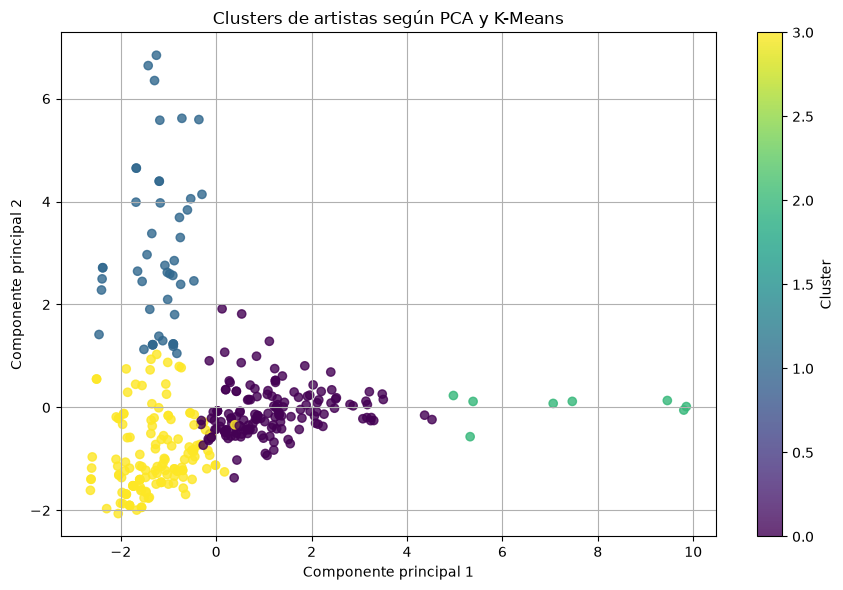

In [49]:
# Visualización de clusters usando los dos primeros componentes principales

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    pca_artistas["PC1"],
    pca_artistas["PC2"],
    c=pca_artistas["cluster"],
    alpha=0.8
)

plt.title("Clusters de artistas según PCA y K-Means")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

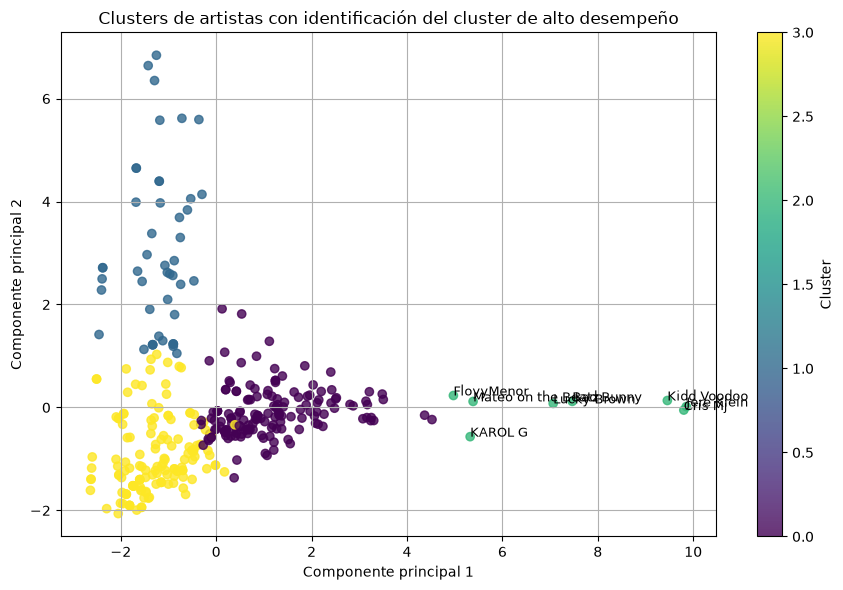

In [50]:
# Visualización de clusters destacando los artistas del cluster 2

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    pca_artistas["PC1"],
    pca_artistas["PC2"],
    c=pca_artistas["cluster"],
    alpha=0.8
)

# Agregar etiquetas solo a los artistas del cluster 2
cluster_2 = pca_artistas[pca_artistas["cluster"] == 2]

for _, row in cluster_2.iterrows():
    plt.text(
        row["PC1"],
        row["PC2"],
        row["artists"],
        fontsize=9
    )

plt.title("Clusters de artistas con identificación del cluster de alto desempeño")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

# Tercera parte: Formativa 4
## 1. Configuración del entorno de desarrollo:
En esta sección se continúa el trabajo realizado en la etapa anterior, utilizando los clusters generados por K-Means como base para construir una etiqueta técnica de alto y bajo desempeño local.

Esta etiqueta no representa ventas reales ni asistencia a eventos, sino una clasificación derivada de los perfiles encontrados previamente. El objetivo es entrenar una red neuronal tipo Perceptrón Multicapa como modelo explicativo y comparar su desempeño bajo distintos escenarios de balanceo.

## 1.1 IDE: Jupyter Lab

## 1.2 Bibliotecas:  
- TensorFlow y Keras: Fueron las bibliotecas seleccionadas como el motor de la fase de construcción y entrenamiento de las redes neuronales.
- Scikit-Learn: Fase de preprocesamiento.
- Pandas y NumPy: Permiten el consumo, estructuración y manipulación de datos.
- Matplotlib y Seaborn: Implementadas para la visualización de rendimiento del modelo.

## 2.	Implementación del modelo 


El problema se estructuró como un modelo de clasificación binaria, donde la red neuronal busca clasificar si un artista pertenece a la clase técnica de alto desempeño local o bajo desempeño local.
Debido a que el clúster de artistas consolidados de alto desempeño local contenía solo 8 de los 351 artistas individualizados, una cantidad reducida para entrenar y validar un clasificador binario de forma independiente, se decidió reagrupar los cuatro clusters según sus perfiles de desempeño.
En esta etapa, el concepto de desempeño local se entiende como una señal digital construida a partir de los rankings diarios de Spotify Chile. Por lo tanto, no representa directamente la convocatoria real de un artista ni su capacidad de llenar un recinto, sino su comportamiento observado dentro de las variables disponibles en el dataset.

In [51]:
# Se agrupan los clusters según su perfil de desempeño observado en la fase anterior.

grupos_alto = [0, 2]   # Presencia sostenida en rankings chilenos + Artistas consolidados de alto desempeño local
grupos_bajo = [1, 3]   # Aparición puntual o comportamiento emergente + Baja presencia o menor posicionamiento local

base_modelo_artistas["alto_potencial"] = base_modelo_artistas["cluster"].apply(
    lambda c: 1 if c in grupos_alto else 0
)

print(base_modelo_artistas["alto_potencial"].value_counts())

alto_potencial
0    186
1    165
Name: count, dtype: int64


### 2.1. Arquitectura de Red Neuronal

Para clasificar perfiles de alto y bajo desempeño local de los artistas, basándose en sus métricas musicales y de desempeño en Spotify, se va a diseñar una arquitectura de red neuronal de tipo Perceptrón Multicapa.

In [52]:
import tensorflow as tf
from tensorflow.keras import Sequential, layers

def construir_modelo(n_inputs, neuronas_1=16, neuronas_2=8, dropout_rate=0.3, learning_rate=0.001):
    """Construye la MLP preliminar con Dropout solo tras la primera capa oculta."""
    modelo = Sequential([
        # Capa de entrada explícita
        layers.Input(shape=(n_inputs,)),

        # Primera capa oculta
        layers.Dense(neuronas_1, activation="relu", name="Capa_Oculta_1"),
        
        # Capa de regularización para evitar sobreajuste
        layers.Dropout(dropout_rate, name="Dropout_1"),

        # Segunda capa oculta
        layers.Dense(neuronas_2, activation="relu", name="Capa_Oculta_2"),

        # Capa de salida (Clasificación binaria)
        layers.Dense(1, activation="sigmoid", name="Capa_Salida")
    ])

    # Compilación del modelo
    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    return modelo

In [53]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception as exc:
    import warnings

    warnings.warn(
        f"No se pudo activar el determinismo de TensorFlow: {exc}",
        RuntimeWarning,
        stacklevel=2,
    )

def reiniciar_entorno(seed=SEED):
    tf.keras.backend.clear_session()
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

# 3. Entrenamiento del modelo 

### 3.1. Definición de Variables (X e y) para Clasificación Binaria

In [54]:
X = base_modelo_artistas[variables_modelo].copy()
y = base_modelo_artistas["alto_potencial"].copy()

print("X:", X.shape)
print("y:", y.shape)

X: (351, 8)
y: (351,)


### 3.2. Entrenamiento / Validación / Prueba (60/20/20, estratificado)

In [55]:
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, stratify=y_train_full, random_state=42
)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Train: (210, 8)
Val:   (70, 8)
Test:  (71, 8)


In [56]:
print("Distribución total:")
print(y.value_counts())
print((y.value_counts(normalize=True) * 100).round(2))

print("\nDistribución Train:")
print(y_train.value_counts())
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nDistribución Validación:")
print(y_val.value_counts())
print((y_val.value_counts(normalize=True) * 100).round(2))

print("\nDistribución Test:")
print(y_test.value_counts())
print((y_test.value_counts(normalize=True) * 100).round(2))

Distribución total:
alto_potencial
0    186
1    165
Name: count, dtype: int64
alto_potencial
0    52.99
1    47.01
Name: proportion, dtype: float64

Distribución Train:
alto_potencial
0    111
1     99
Name: count, dtype: int64
alto_potencial
0    52.86
1    47.14
Name: proportion, dtype: float64

Distribución Validación:
alto_potencial
0    37
1    33
Name: count, dtype: int64
alto_potencial
0    52.86
1    47.14
Name: proportion, dtype: float64

Distribución Test:
alto_potencial
0    38
1    33
Name: count, dtype: int64
alto_potencial
0    53.52
1    46.48
Name: proportion, dtype: float64


### 3.3. Estandarización de las variables 

Estandarizar variables con StandardScaler, para evitar cualquier tipo de fuga hacia las etapas de evaluación.

In [57]:
from sklearn.preprocessing import StandardScaler

scaler_nn = StandardScaler()
X_train_scaled = scaler_nn.fit_transform(X_train)
X_val_scaled = scaler_nn.transform(X_val)
X_test_scaled = scaler_nn.transform(X_test)

### 3.4. Construcción e Inspección de la Arquitectura de la Red Neuronal

Inspección de la arquitectura antes de iniciar el entrenamiento con el objetivo de verificar estructura de capas y parámetros entrenables.

> **Nota:** Este es un modelo preliminar con ponderación de clases. Su topología de Dropout difiere de MLP_16_8 de la comparación experimental y no interviene en la selección del modelo final.

In [58]:
reiniciar_entorno()

print("Arquitectura de la red neuronal")

modelo_nn = construir_modelo(
    n_inputs=X_train_scaled.shape[1],
    neuronas_1=16,
    neuronas_2=8,
    dropout_rate=0.30,
    learning_rate=0.001
)

modelo_nn.summary()

Arquitectura de la red neuronal

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Capa_Oculta_1 (Dense)           │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Oculta_2 (Dense)           │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Salida (Dense)             │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

### 3.5. Balanceo de clases

Como la variable objetivo presenta un desbalance entre las clases de alto y bajo desempeño local, se incorpora inicialmente una estrategia de ponderación de clases. Esta técnica permite asignar mayor peso a la clase minoritaria durante el entrenamiento, sin modificar la cantidad original de registros.
Esta estrategia se considera como una primera aproximación al tratamiento del desbalance. En una etapa posterior, sus resultados podrán compararse con otras técnicas, como sobremuestreo y submuestreo, para analizar su efecto sobre el rendimiento del modelo.

In [59]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

clases = np.unique(y_train)
pesos = compute_class_weight(class_weight="balanced", classes=clases, y=y_train)
class_weight_dict = dict(zip(clases, pesos))

print("Pesos de clase calculados:", class_weight_dict)

Pesos de clase calculados: {np.int64(0): np.float64(0.9459459459459459), np.int64(1): np.float64(1.0606060606060606)}


### 3.6. Entrenamiento y ajuste de hiperparámetros

En esta etapa se procede a compilar y entrenar el modelo utilizando los datos escalados. Para favorecer un entrenamiento estable y reducir el riesgo de sobreajuste, se configuraron los siguientes parámetros:

* Ponderación de clases: Se integra el diccionario de pesos previamente calculado para penalizar con mayor severidad los errores sobre la clase minoritaria.
* Early Stopping: Se monitorea la métrica de pérdida de validación. Si el modelo no presenta mejoras durante 10 épocas consecutivas, el entrenamiento se detiene automáticamente y se restauran los pesos de la mejor iteración, previniendo así el sobreajuste.
* Ciclos y lotes: Se establece un límite máximo de 100 épocas de entrenamiento, actualizando los gradientes en lotes de 32 muestras.

In [60]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

historia = modelo_nn.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/100


7/7 - 2s - 217ms/step - accuracy: 0.4667 - auc: 0.3284 - loss: 0.8218 - val_accuracy: 0.4714 - val_auc: 0.3522 - val_loss: 0.7994


Epoch 2/100


7/7 - 0s - 19ms/step - accuracy: 0.4714 - auc: 0.3773 - loss: 0.7823 - val_accuracy: 0.4714 - val_auc: 0.4296 - val_loss: 0.7754


Epoch 3/100


...

7/7 - 0s - 13ms/step - accuracy: 0.9952 - auc: 1.0000 - loss: 0.2310 - val_accuracy: 0.9857 - val_auc: 0.9992 - val_loss: 0.2387


Epoch 99/100


7/7 - 0s - 13ms/step - accuracy: 0.9905 - auc: 0.9998 - loss: 0.2314 - val_accuracy: 0.9857 - val_auc: 0.9992 - val_loss: 0.2376


Epoch 100/100


7/7 - 0s - 13ms/step - accuracy: 0.9857 - auc: 0.9998 - loss: 0.2293 - val_accuracy: 0.9857 - val_auc: 0.9992 - val_loss: 0.2367


### 3.7. Resultados del entrenamiento

Registramos función de pérdida y exactitud en cada época. 
Las curvas de entrenamiento permiten observar la evolución de la pérdida y la exactitud durante las épocas de entrenamiento. En términos generales, la disminución progresiva de la pérdida indica que el modelo logra aprender patrones presentes en los datos de entrenamiento. La comparación entre las curvas de entrenamiento y validación permite revisar si existe una brecha de generalización o señales de sobreajuste, considerando que EarlyStopping restaura los pesos asociados al mejor desempeño observado en validación.

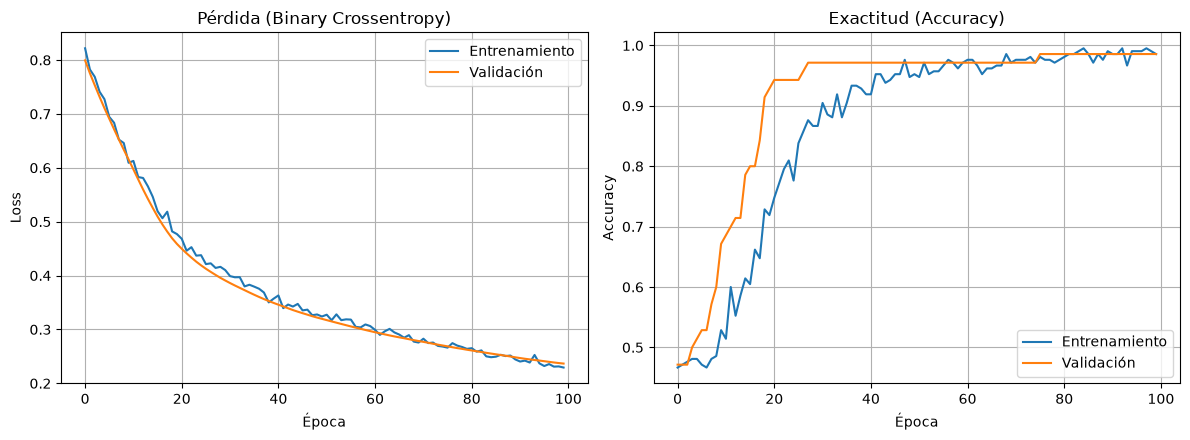

El entrenamiento finalizó en la época 100


In [61]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(historia.history["loss"], label="Entrenamiento")
axes[0].plot(historia.history["val_loss"], label="Validación")
axes[0].set_title("Pérdida (Binary Crossentropy)")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(historia.history["accuracy"], label="Entrenamiento")
axes[1].plot(historia.history["val_accuracy"], label="Validación")
axes[1].set_title("Exactitud (Accuracy)")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"El entrenamiento finalizó en la época {len(historia.history['loss'])}")

### Revisión de pérdida final

In [62]:
print("Loss final entrenamiento:", historia.history["loss"][-1])
print("Loss final validación:", historia.history["val_loss"][-1])

Loss final entrenamiento: 0.22930407524108887
Loss final validación: 0.236675426363945


### 3.8 Comparación complementaria de estrategias de balanceo

Además del modelo entrenado con ponderación de clases, se realiza una comparación complementaria con otros escenarios de balanceo. El objetivo de esta sección es analizar si el tratamiento del desbalance de clases modifica el rendimiento del modelo MLP.

Para esto, se evaluarán cuatro escenarios: modelo sin balanceo, modelo con ponderación de clases, modelo con sobremuestreo de la clase minoritaria y modelo con submuestreo de la clase mayoritaria. Esta comparación permite observar si las estrategias de balanceo mejoran, mantienen o reducen el desempeño obtenido por el modelo principal.

In [63]:
# Escenario 1: modelo sin balanceo

from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd

reiniciar_entorno()

modelo_sin_balanceo = construir_modelo(n_inputs=X_train_scaled.shape[1])

early_stop_sin_balanceo = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

historia_sin_balanceo = modelo_sin_balanceo.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_sin_balanceo],
    verbose=0
)

hist_sin_balanceo_df = pd.DataFrame(historia_sin_balanceo.history)

val_loss_sin, val_accuracy_sin, val_auc_sin = modelo_sin_balanceo.evaluate(
    X_val_scaled,
    y_val,
    verbose=0
)

print("Resultados en validación - modelo sin balanceo")
print(f"Épocas entrenadas: {len(hist_sin_balanceo_df)}")
print(f"Loss: {val_loss_sin:.4f}")
print(f"Accuracy: {val_accuracy_sin:.4f}")
print(f"AUC: {val_auc_sin:.4f}")

Resultados en validación - modelo sin balanceo
Épocas entrenadas: 100
Loss: 0.2367
Accuracy: 0.9857
AUC: 0.9992


In [64]:
# Escenario 2: modelo con sobremuestreo de la clase minoritaria

from sklearn.utils import resample
import pandas as pd

train_df = pd.DataFrame(X_train_scaled, columns=variables_modelo)
train_df["alto_potencial"] = y_train.reset_index(drop=True).values

train_clase_0 = train_df[train_df["alto_potencial"] == 0]
train_clase_1 = train_df[train_df["alto_potencial"] == 1]

print("Distribución original en entrenamiento:")
print(train_df["alto_potencial"].value_counts())

if len(train_clase_0) >= len(train_clase_1):
    clase_mayoritaria = train_clase_0
    clase_minoritaria = train_clase_1
else:
    clase_mayoritaria = train_clase_1
    clase_minoritaria = train_clase_0

clase_minoritaria_over = resample(
    clase_minoritaria,
    replace=True,
    n_samples=len(clase_mayoritaria),
    random_state=42
)

train_over_df = pd.concat([clase_mayoritaria, clase_minoritaria_over])
train_over_df = train_over_df.sample(frac=1, random_state=42).reset_index(drop=True)

X_train_over = train_over_df[variables_modelo].values
y_train_over = train_over_df["alto_potencial"].values

print("\nDistribución después del sobremuestreo:")
print(pd.Series(y_train_over).value_counts())

reiniciar_entorno()

modelo_sobremuestreo = construir_modelo(n_inputs=X_train_scaled.shape[1])

early_stop_sobremuestreo = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

historia_sobremuestreo = modelo_sobremuestreo.fit(
    X_train_over,
    y_train_over,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_sobremuestreo],
    verbose=0
)

hist_sobremuestreo_df = pd.DataFrame(historia_sobremuestreo.history)

val_loss_over, val_accuracy_over, val_auc_over = modelo_sobremuestreo.evaluate(
    X_val_scaled,
    y_val,
    verbose=0
)

print("\nResultados en validación - modelo con sobremuestreo")
print(f"Épocas entrenadas: {len(hist_sobremuestreo_df)}")
print(f"Loss: {val_loss_over:.4f}")
print(f"Accuracy: {val_accuracy_over:.4f}")
print(f"AUC: {val_auc_over:.4f}")

Distribución original en entrenamiento:
alto_potencial
0    111
1     99
Name: count, dtype: int64

Distribución después del sobremuestreo:
1    111
0    111
Name: count, dtype: int64



Resultados en validación - modelo con sobremuestreo
Épocas entrenadas: 100
Loss: 0.2353
Accuracy: 0.9857
AUC: 0.9992


In [65]:
# Escenario 3: modelo con submuestreo de la clase mayoritaria

from sklearn.utils import resample
import pandas as pd

train_df = pd.DataFrame(X_train_scaled, columns=variables_modelo)
train_df["alto_potencial"] = y_train.reset_index(drop=True).values

train_clase_0 = train_df[train_df["alto_potencial"] == 0]
train_clase_1 = train_df[train_df["alto_potencial"] == 1]

print("Distribución original en entrenamiento:")
print(train_df["alto_potencial"].value_counts())

if len(train_clase_0) >= len(train_clase_1):
    clase_mayoritaria = train_clase_0
    clase_minoritaria = train_clase_1
else:
    clase_mayoritaria = train_clase_1
    clase_minoritaria = train_clase_0

clase_mayoritaria_under = resample(
    clase_mayoritaria,
    replace=False,
    n_samples=len(clase_minoritaria),
    random_state=42
)

train_under_df = pd.concat([clase_mayoritaria_under, clase_minoritaria])
train_under_df = train_under_df.sample(frac=1, random_state=42).reset_index(drop=True)

X_train_under = train_under_df[variables_modelo].values
y_train_under = train_under_df["alto_potencial"].values

print("\nDistribución después del submuestreo:")
print(pd.Series(y_train_under).value_counts())

reiniciar_entorno()

modelo_submuestreo = construir_modelo(n_inputs=X_train_scaled.shape[1])

early_stop_submuestreo = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

historia_submuestreo = modelo_submuestreo.fit(
    X_train_under,
    y_train_under,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_submuestreo],
    verbose=0
)

hist_submuestreo_df = pd.DataFrame(historia_submuestreo.history)

val_loss_under, val_accuracy_under, val_auc_under = modelo_submuestreo.evaluate(
    X_val_scaled,
    y_val,
    verbose=0
)

print("\nResultados en validación - modelo con submuestreo")
print(f"Épocas entrenadas: {len(hist_submuestreo_df)}")
print(f"Loss: {val_loss_under:.4f}")
print(f"Accuracy: {val_accuracy_under:.4f}")
print(f"AUC: {val_auc_under:.4f}")

Distribución original en entrenamiento:
alto_potencial
0    111
1     99
Name: count, dtype: int64

Distribución después del submuestreo:
0    99
1    99
Name: count, dtype: int64



Resultados en validación - modelo con submuestreo
Épocas entrenadas: 100
Loss: 0.2393
Accuracy: 0.9857
AUC: 1.0000


In [66]:
# Resultados de validación del modelo con ponderación de clases

val_loss_cw, val_accuracy_cw, val_auc_cw = modelo_nn.evaluate(
    X_val_scaled,
    y_val,
    verbose=0
)

print("Resultados en validación - modelo con ponderación de clases")
print(f"Loss: {val_loss_cw:.4f}")
print(f"Accuracy: {val_accuracy_cw:.4f}")
print(f"AUC: {val_auc_cw:.4f}")

Resultados en validación - modelo con ponderación de clases
Loss: 0.2367
Accuracy: 0.9857
AUC: 0.9992


In [67]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluar_binario(modelo, X_eval, y_eval, nombre, umbral=0.5):
    loss, _, _ = modelo.evaluate(X_eval, y_eval, verbose=0)
    
    probabilidades = modelo.predict(X_eval, verbose=0).ravel()
    predicciones = (probabilidades >= umbral).astype(int)

    return {
        "Escenario": nombre,
        "Loss_validacion": loss,
        "Accuracy_validacion": accuracy_score(y_eval, predicciones),
        "Precision_validacion": precision_score(y_eval, predicciones, zero_division=0),
        "Recall_validacion": recall_score(y_eval, predicciones, zero_division=0),
        "F1_validacion": f1_score(y_eval, predicciones, zero_division=0),
        "AUC_validacion": roc_auc_score(y_eval, probabilidades)
    }

resultados_balanceo = [
    evaluar_binario(modelo_sin_balanceo, X_val_scaled, y_val, "Sin balanceo"),
    evaluar_binario(modelo_nn, X_val_scaled, y_val, "Ponderación de clases"),
    evaluar_binario(modelo_sobremuestreo, X_val_scaled, y_val, "Sobremuestreo"),
    evaluar_binario(modelo_submuestreo, X_val_scaled, y_val, "Submuestreo")
]

comparacion_balanceo = (
    pd.DataFrame(resultados_balanceo)
    .sort_values(["F1_validacion", "AUC_validacion"], ascending=False)
    .reset_index(drop=True)
)

display(comparacion_balanceo.round(4))

,Escenario,Loss_validacion,Accuracy_validacion,Precision_validacion,Recall_validacion,F1_validacion,AUC_validacion
0,Submuestreo,0.2393,0.9857,1.0,0.9697,0.9846,1.0000
1,Sin balanceo,0.2367,0.9857,1.0,0.9697,0.9846,0.9992
2,Ponderación de clases,0.2367,0.9857,1.0,0.9697,0.9846,0.9992
3,Sobremuestreo,0.2353,0.9857,1.0,0.9697,0.9846,0.9992


### Interpretación de la comparación de estrategias de balanceo

Al comparar los cuatro escenarios sobre el conjunto de validación, sus resultados son muy próximos y no permiten establecer una diferencia estadística concluyente entre las estrategias. El orden de la tabla responde únicamente a F1-score y AUC, por lo que debe interpretarse como una clasificación descriptiva de esta partición.

Aunque el submuestreo aparece primero en la tabla, descarta registros de la clase mayoritaria. Para la comparación de arquitecturas se mantiene el sobremuestreo porque conserva toda la información original y equilibra las clases mediante réplicas de la clase minoritaria. Esta decisión define los datos de entrenamiento, mientras que la arquitectura final se selecciona posteriormente usando solo el conjunto de validación.

Los resultados deben interpretarse con cautela porque la variable objetivo corresponde a una etiqueta técnica derivada de los clusters. El modelo reproduce una clasificación de señal digital local en Spotify Chile y no una medición directa de convocatoria real, venta de entradas o asistencia a eventos.

## Comparación experimental de tres arquitecturas MLP

Las tres configuraciones se entrenan con el mismo conjunto sobremuestreado
(`X_train_over`, `y_train_over`) y se comparan exclusivamente con validación
(`X_val_scaled`, `y_val`). El conjunto de prueba no participa en el
entrenamiento ni en la selección de la arquitectura.


Los resultados se ordenan por menor `val_loss`, mayor F1 y mayor AUC. Se consideran prácticamente equivalentes cuando los tres criterios difieren como máximo en 0.001; solo en ese caso se prefiere la arquitectura con menos parámetros y capas ocultas.

In [68]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from tensorflow.keras import Sequential, layers
from tensorflow.keras.callbacks import EarlyStopping

SEMILLA_ARQUITECTURAS = 42
UMBRAL_CLASIFICACION = 0.5
TOLERANCIA_EQUIVALENCIA = 0.001
RESULTADOS_ARQUITECTURAS_DIR = Path("resultados_arquitecturas")
RESULTADOS_ARQUITECTURAS_DIR.mkdir(parents=True, exist_ok=True)

CONFIGURACIONES_MLP = [
    {
        "nombre": "MLP_16_8",
        "capas_ocultas": [16, 8],
        "dropout": 0.30,
        "learning_rate": 0.001,
        "archivo_perdida": "MLP_16_8_perdida.png",
        "archivo_exactitud": "MLP_16_8_exactitud.png",
    },
    {
        "nombre": "MLP_32_16",
        "capas_ocultas": [32, 16],
        "dropout": 0.40,
        "learning_rate": 0.0005,
        "archivo_perdida": "MLP_32_16_perdida.png",
        "archivo_exactitud": "MLP_32_16_exactitud.png",
    },
    {
        "nombre": "MLP_1_capa",
        "capas_ocultas": [16],
        "dropout": 0.20,
        "learning_rate": 0.002,
        "archivo_perdida": "MLP_1_capa_perdida.png",
        "archivo_exactitud": "MLP_1_capa_exactitud.png",
    },
]


def fijar_semilla_arquitectura(seed=SEMILLA_ARQUITECTURAS):
    tf.keras.backend.clear_session()
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


def construir_mlp_experimental(
    n_inputs,
    capas_ocultas,
    dropout,
    learning_rate,
):
    """Construye una MLP experimental con Dropout tras cada capa oculta."""
    modelo = Sequential()
    modelo.add(layers.Input(shape=(n_inputs,)))
    for indice, unidades in enumerate(capas_ocultas, start=1):
        modelo.add(
            layers.Dense(
                unidades,
                activation="relu",
                name=f"Capa_Oculta_{indice}",
            )
        )
        modelo.add(layers.Dropout(dropout, name=f"Dropout_{indice}"))
    modelo.add(layers.Dense(1, activation="sigmoid", name="Capa_Salida"))
    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return modelo


def guardar_curva(
    historial,
    metrica_entrenamiento,
    metrica_validacion,
    mejor_epoca,
    titulo,
    etiqueta_y,
    ruta_salida,
):
    epocas = np.arange(1, len(historial[metrica_entrenamiento]) + 1)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(epocas, historial[metrica_entrenamiento], label="Entrenamiento")
    ax.plot(epocas, historial[metrica_validacion], label="Validación")
    ax.axvline(
        mejor_epoca,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label=f"Mejor época: {mejor_epoca}",
    )
    ax.set_title(titulo)
    ax.set_xlabel("Época")
    ax.set_ylabel(etiqueta_y)
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(ruta_salida, dpi=300, bbox_inches="tight")
    plt.close(fig)


In [69]:
resultados_arquitecturas = []
modelos_arquitecturas = {}
historias_arquitecturas = {}

for configuracion in CONFIGURACIONES_MLP:
    # La semilla se restablece inmediatamente antes de construir cada modelo.
    fijar_semilla_arquitectura(SEMILLA_ARQUITECTURAS)

    modelo = construir_mlp_experimental(
        n_inputs=X_train_over.shape[1],
        capas_ocultas=configuracion["capas_ocultas"],
        dropout=configuracion["dropout"],
        learning_rate=configuracion["learning_rate"],
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        min_delta=0.0001,
        restore_best_weights=True,
    )

    historia_modelo = modelo.fit(
        # Se mantiene el sobremuestreo para comparar arquitecturas: aunque la
        # tabla ordene primero al submuestreo, este descarta registros de la
        # clase mayoritaria y las cuatro estrategias presentan resultados muy
        # próximos en la partición de validación utilizada.
        X_train_over,
        y_train_over,
        validation_data=(X_val_scaled, y_val),
        batch_size=32,
        epochs=150,
        callbacks=[early_stopping],
        verbose=0,
    )

    historial = historia_modelo.history
    indice_mejor_epoca = int(early_stopping.best_epoch)
    mejor_epoca = indice_mejor_epoca + 1

    # Todas las métricas se calculan después de que EarlyStopping restaura
    # sus mejores pesos. El historial se conserva solo para las curvas.
    metricas_val = modelo.evaluate(
        X_val_scaled,
        y_val,
        verbose=0,
        return_dict=True,
    )

    # Keras 3 conserva la firma usada con validation_data. Se reconstruye
    # la función de evaluación para aceptar y_train_over como ndarray;
    # esta operación no modifica los pesos restaurados del modelo.
    modelo.make_test_function(force=True)
    metricas_train = modelo.evaluate(
        X_train_over,
        y_train_over,
        verbose=0,
        return_dict=True,
    )

    probabilidades_val = modelo.predict(X_val_scaled, verbose=0).ravel()
    predicciones_val = (
        probabilidades_val >= UMBRAL_CLASIFICACION
    ).astype(int)

    brecha_loss_val_menos_train = float(
        metricas_val["loss"] - metricas_train["loss"]
    )
    brecha_accuracy_train_menos_val = float(
        metricas_train["accuracy"] - metricas_val["accuracy"]
    )

    resultado = {
        "modelo": configuracion["nombre"],
        "capas_ocultas": list(configuracion["capas_ocultas"]),
        "numero_capas_ocultas": len(configuracion["capas_ocultas"]),
        "dropout": float(configuracion["dropout"]),
        "learning_rate": float(configuracion["learning_rate"]),
        "parametros": int(modelo.count_params()),
        "epocas_ejecutadas": int(len(historial["loss"])),
        "mejor_epoca": int(mejor_epoca),
        "loss_validacion": float(metricas_val["loss"]),
        "accuracy": float(metricas_val["accuracy"]),
        "precision": float(
            precision_score(y_val, predicciones_val, zero_division=0)
        ),
        "recall": float(
            recall_score(y_val, predicciones_val, zero_division=0)
        ),
        "f1": float(
            f1_score(y_val, predicciones_val, zero_division=0)
        ),
        "auc": float(roc_auc_score(y_val, probabilidades_val)),
        "brecha_loss_val_menos_train": brecha_loss_val_menos_train,
        "brecha_accuracy_train_menos_val": brecha_accuracy_train_menos_val,
    }

    resultados_arquitecturas.append(resultado)
    modelos_arquitecturas[configuracion["nombre"]] = modelo
    historias_arquitecturas[configuracion["nombre"]] = historial

    guardar_curva(
        historial=historial,
        metrica_entrenamiento="loss",
        metrica_validacion="val_loss",
        mejor_epoca=mejor_epoca,
        titulo=f"{configuracion['nombre']}: pérdida",
        etiqueta_y="Binary crossentropy",
        ruta_salida=(
            RESULTADOS_ARQUITECTURAS_DIR
            / configuracion["archivo_perdida"]
        ),
    )
    guardar_curva(
        historial=historial,
        metrica_entrenamiento="accuracy",
        metrica_validacion="val_accuracy",
        mejor_epoca=mejor_epoca,
        titulo=f"{configuracion['nombre']}: exactitud",
        etiqueta_y="Accuracy",
        ruta_salida=(
            RESULTADOS_ARQUITECTURAS_DIR
            / configuracion["archivo_exactitud"]
        ),
    )

tabla_arquitecturas = pd.DataFrame(resultados_arquitecturas)
tabla_comparativa_arquitecturas = (
    tabla_arquitecturas
    .sort_values(
        by=["loss_validacion", "f1", "auc"],
        ascending=[True, False, False],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

# Solo se aplica el desempate por simplicidad si los tres criterios de
# ordenación están dentro de la tolerancia respecto del primer modelo.
referencia = tabla_comparativa_arquitecturas.iloc[0]
mascara_equivalentes = (
    (
        tabla_comparativa_arquitecturas["loss_validacion"]
        - referencia["loss_validacion"]
    ).abs()
    <= TOLERANCIA_EQUIVALENCIA
) & (
    (
        tabla_comparativa_arquitecturas["f1"]
        - referencia["f1"]
    ).abs()
    <= TOLERANCIA_EQUIVALENCIA
) & (
    (
        tabla_comparativa_arquitecturas["auc"]
        - referencia["auc"]
    ).abs()
    <= TOLERANCIA_EQUIVALENCIA
)

modelos_equivalentes = tabla_comparativa_arquitecturas[
    mascara_equivalentes
]
fila_seleccionada = (
    modelos_equivalentes
    .sort_values(
        by=[
            "parametros",
            "numero_capas_ocultas",
            "loss_validacion",
            "f1",
            "auc",
        ],
        ascending=[True, True, True, False, False],
        kind="mergesort",
    )
    .iloc[0]
)

nombre_modelo_seleccionado = str(fila_seleccionada["modelo"])
modelo_final = modelos_arquitecturas[nombre_modelo_seleccionado]

columnas_mostrar = [
    "modelo",
    "capas_ocultas",
    "dropout",
    "learning_rate",
    "parametros",
    "epocas_ejecutadas",
    "mejor_epoca",
    "loss_validacion",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "auc",
    "brecha_loss_val_menos_train",
    "brecha_accuracy_train_menos_val",
]
display(
    tabla_comparativa_arquitecturas[columnas_mostrar].round(6)
)
print("Modelo seleccionado:", nombre_modelo_seleccionado)
print(
    "Selección realizada solo con validación; "
    "X_test_scaled no se utilizó."
)

salida_json = {
    "versiones": globals().get("VERSIONES_ENTORNO", {}),
    "semilla": SEMILLA_ARQUITECTURAS,
    "datos_entrenamiento": "X_train_over, y_train_over",
    "datos_seleccion": "X_val_scaled, y_val",
    "conjunto_prueba_usado_en_seleccion": False,
    "batch_size": 32,
    "max_epocas": 150,
    "early_stopping": {
        "monitor": "val_loss",
        "patience": 10,
        "min_delta": 0.0001,
        "restore_best_weights": True,
    },
    "umbral_clasificacion": UMBRAL_CLASIFICACION,
    "criterios_orden": [
        "menor loss_validacion",
        "mayor f1",
        "mayor auc",
    ],
    "tolerancia_equivalencia": TOLERANCIA_EQUIVALENCIA,
    "desempate": "menor cantidad de parámetros y capas ocultas",
    "modelo_seleccionado": nombre_modelo_seleccionado,
    "resultados": (
        tabla_comparativa_arquitecturas[columnas_mostrar]
        .to_dict(orient="records")
    ),
}

ruta_json = (
    RESULTADOS_ARQUITECTURAS_DIR
    / "comparacion_arquitecturas.json"
)
with ruta_json.open("w", encoding="utf-8") as archivo_json:
    json.dump(
        salida_json,
        archivo_json,
        ensure_ascii=False,
        indent=2,
    )

encabezados_md = [
    "Modelo",
    "Capas",
    "Dropout",
    "LR",
    "Parámetros",
    "Épocas",
    "Mejor época",
    "Val loss",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "AUC",
    "Brecha loss (val-train)",
    "Brecha accuracy (train-val)",
]
lineas_tabla = [
    "| " + " | ".join(encabezados_md) + " |",
    "| " + " | ".join(["---"] * len(encabezados_md)) + " |",
]
for _, fila in tabla_comparativa_arquitecturas.iterrows():
    valores = [
        str(fila["modelo"]),
        str(fila["capas_ocultas"]),
        f"{fila['dropout']:.2f}",
        f"{fila['learning_rate']:.6f}",
        str(int(fila["parametros"])),
        str(int(fila["epocas_ejecutadas"])),
        str(int(fila["mejor_epoca"])),
        f"{fila['loss_validacion']:.6f}",
        f"{fila['accuracy']:.6f}",
        f"{fila['precision']:.6f}",
        f"{fila['recall']:.6f}",
        f"{fila['f1']:.6f}",
        f"{fila['auc']:.6f}",
        f"{fila['brecha_loss_val_menos_train']:.6f}",
        f"{fila['brecha_accuracy_train_menos_val']:.6f}",
    ]
    lineas_tabla.append("| " + " | ".join(valores) + " |")

contenido_resumen = [
    "# Comparación experimental de tres arquitecturas MLP",
    "",
    f"**Modelo seleccionado:** {nombre_modelo_seleccionado}",
    "",
    (
        "Orden: menor loss de validación, mayor F1 y mayor AUC. "
        "Si loss, F1 y AUC difieren como máximo en "
        f"{TOLERANCIA_EQUIVALENCIA}, se elige el modelo más simple."
    ),
    "",
    *lineas_tabla,
    "",
    (
        "La selección utilizó únicamente el conjunto de validación; "
        "el conjunto de prueba quedó reservado para la evaluación final."
    ),
]
ruta_resumen = (
    RESULTADOS_ARQUITECTURAS_DIR
    / "resumen_arquitecturas.md"
)
_ = ruta_resumen.write_text(
    "\n".join(contenido_resumen) + "\n",
    encoding="utf-8",
)


,modelo,capas_ocultas,dropout,learning_rate,parametros,epocas_ejecutadas,mejor_epoca,loss_validacion,accuracy,precision,recall,f1,auc,brecha_loss_val_menos_train,brecha_accuracy_train_menos_val
0,MLP_16_8,"[16, 8]",0.3,0.0010,289,126,116,0.023691,0.985714,1.0,0.969697,0.984615,1.000000,-0.000056,0.005277
1,MLP_1_capa,[16],0.2,0.0020,161,127,117,0.028673,0.985714,1.0,0.969697,0.984615,0.999181,0.007962,0.014286
2,MLP_32_16,"[32, 16]",0.4,0.0005,833,141,131,0.036272,0.985714,1.0,0.969697,0.984615,0.999181,0.016890,0.014286


Modelo seleccionado: MLP_16_8
Selección realizada solo con validación; X_test_scaled no se utilizó.


### 3.9 Evaluación final del modelo seleccionado

El modelo final se seleccionó comparando las tres arquitecturas MLP sobre el conjunto de validación. Los criterios principales fueron menor pérdida de validación, mayor F1-score y mayor AUC; el nombre de la arquitectura seleccionada queda registrado en `nombre_modelo_seleccionado`.

El sobremuestreo se mantiene como estrategia de balanceo del conjunto de entrenamiento para las tres arquitecturas, pero no constituye el criterio de selección del modelo. A continuación, se evalúa `modelo_final` sobre el conjunto de prueba, que permaneció aislado durante el entrenamiento y la selección.

Es importante señalar que esta evaluación no mide convocatoria real, venta de entradas ni asistencia a eventos. El modelo evalúa la capacidad de reproducir una etiqueta técnica construida a partir de los clusters y de las variables disponibles en Spotify Chile.

In [70]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


y_test_prob = modelo_final.predict(X_test_scaled, verbose=0).ravel()
y_test_pred = (
    y_test_prob >= UMBRAL_CLASIFICACION
).astype(int)

accuracy_final = accuracy_score(y_test, y_test_pred)
precision_final = precision_score(y_test, y_test_pred, zero_division=0)
recall_final = recall_score(y_test, y_test_pred, zero_division=0)
f1_final = f1_score(y_test, y_test_pred, zero_division=0)
auc_final = roc_auc_score(y_test, y_test_prob)

matriz_confusion = confusion_matrix(y_test, y_test_pred)

print(
    "Evaluación final en conjunto de prueba - "
    f"{nombre_modelo_seleccionado}"
)
print(f"Accuracy:  {accuracy_final:.4f}")
print(f"Precision: {precision_final:.4f}")
print(f"Recall:    {recall_final:.4f}")
print(f"F1-score:  {f1_final:.4f}")
print(f"AUC:       {auc_final:.4f}")

print("\nMatriz de confusión:")
print(matriz_confusion)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_test_pred, zero_division=0))

Evaluación final en conjunto de prueba - MLP_16_8
Accuracy:  0.9859
Precision: 1.0000
Recall:    0.9697
F1-score:  0.9846
AUC:       0.9992

Matriz de confusión:
[[38  0]
 [ 1 32]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        38
           1       1.00      0.97      0.98        33

    accuracy                           0.99        71
   macro avg       0.99      0.98      0.99        71
weighted avg       0.99      0.99      0.99        71



In [71]:
verdaderos_negativos = int(matriz_confusion[0, 0])
falsos_positivos = int(matriz_confusion[0, 1])
falsos_negativos = int(matriz_confusion[1, 0])
verdaderos_positivos = int(matriz_confusion[1, 1])

texto_interpretacion_final = (
    f"Los resultados obtenidos en el conjunto de prueba muestran el desempeño "
    f"del modelo {nombre_modelo_seleccionado}. El modelo alcanzó una exactitud "
    f"de {accuracy_final:.4f}, una precisión de {precision_final:.4f}, un recall "
    f"de {recall_final:.4f}, un F1-score de {f1_final:.4f} y un AUC de "
    f"{auc_final:.4f}. La matriz de confusión contiene {verdaderos_negativos} "
    f"verdaderos negativos, {falsos_positivos} falsos positivos, "
    f"{falsos_negativos} falsos negativos y {verdaderos_positivos} verdaderos "
    f"positivos. Estos resultados indican la capacidad de la red para reproducir "
    f"la etiqueta técnica definida a partir de los perfiles de Spotify Chile. "
    f"No deben interpretarse como evidencia de convocatoria real, venta de "
    f"entradas o asistencia a eventos, porque la variable objetivo fue construida "
    f"a partir de los clusters y no de esas mediciones reales."
)

print(texto_interpretacion_final)

Los resultados obtenidos en el conjunto de prueba muestran el desempeño del modelo MLP_16_8. El modelo alcanzó una exactitud de 0.9859, una precisión de 1.0000, un recall de 0.9697, un F1-score de 0.9846 y un AUC de 0.9992. La matriz de confusión contiene 38 verdaderos negativos, 0 falsos positivos, 1 falsos negativos y 32 verdaderos positivos. Estos resultados indican la capacidad de la red para reproducir la etiqueta técnica definida a partir de los perfiles de Spotify Chile. No deben interpretarse como evidencia de convocatoria real, venta de entradas o asistencia a eventos, porque la variable objetivo fue construida a partir de los clusters y no de esas mediciones reales.


### 3.10 Visualización de la matriz de confusión

Para complementar la evaluación final del modelo seleccionado, se construye una matriz de confusión gráfica. Esta visualización permite observar cuántos artistas fueron clasificados correctamente en cada clase y cuántos casos fueron clasificados de forma incorrecta frente a datos no observados.

La matriz permite distinguir los verdaderos negativos, verdaderos positivos, falsos positivos y falsos negativos, facilitando la interpretación del rendimiento del modelo más allá de las métricas globales. En este proyecto, las clases representan una etiqueta técnica de menor o mayor señal digital local en Spotify Chile, no una medición directa de convocatoria real.

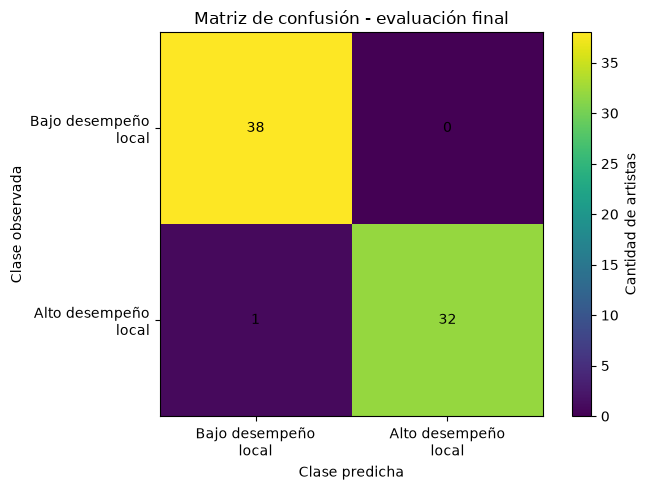

In [72]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7, 5))

plt.imshow(matriz_confusion)

plt.title("Matriz de confusión - evaluación final")
plt.xlabel("Clase predicha")
plt.ylabel("Clase observada")

clases_nombre = ["Bajo desempeño\nlocal", "Alto desempeño\nlocal"]

plt.xticks(ticks=np.arange(2), labels=clases_nombre)
plt.yticks(ticks=np.arange(2), labels=clases_nombre)

for i in range(matriz_confusion.shape[0]):
    for j in range(matriz_confusion.shape[1]):
        plt.text(
            j,
            i,
            matriz_confusion[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(label="Cantidad de artistas")
plt.tight_layout()
plt.show()

### 3.11 Explicabilidad del modelo

In [73]:
# Verificar si la librería SHAP está instalada

import importlib.util

shap_disponible = importlib.util.find_spec("shap") is not None

if shap_disponible:
    import shap
    print("SHAP está instalado.")
    print("Versión de SHAP:", shap.__version__)
else:
    print("SHAP no está instalado en este entorno.")
    print("Antes de continuar, se debe instalar la librería shap.")

SHAP está instalado.
Versión de SHAP: 0.51.0


### Nota sobre dependencias

Para ejecutar la sección de explicabilidad con SHAP, el entorno debe tener instalada la librería `shap`. Las dependencias del proyecto se declaran fuera del notebook, en el archivo `requirements.txt`, para evitar modificar el entorno de ejecución durante el análisis.

In [74]:
import shap
print(shap.__version__)

0.51.0


  0%|          | 0/50 [00:00<?, ?it/s]

Importancia de variables según SHAP:


,Variable,Importancia_SHAP
0,puntaje_posicion_chile,0.189680
1,rank_promedio_chile,0.129339
2,movimiento_semanal_promedio,0.070992
3,permanencia_dias,0.065620
4,popularidad_promedio,0.037012
5,movimiento_diario_promedio,0.026034
6,apariciones_chile,0.020372
7,canciones_unicas_chile,0.007254


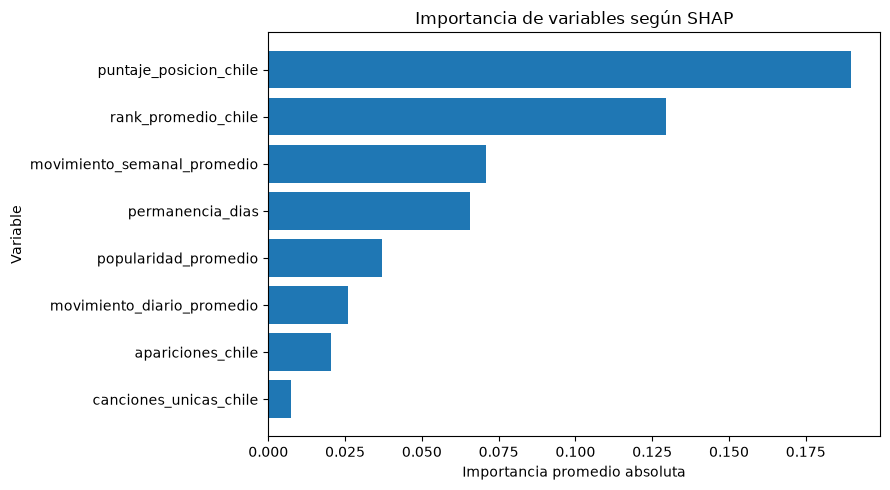

In [75]:
# Explicación del modelo seleccionado con SHAP

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Muestras reproducibles
X_background = shap.sample(X_train_scaled, 50, random_state=SEED)
X_explicar = X_test_scaled[:50]

def predecir_modelo(datos):
    return modelo_final.predict(datos, verbose=0).ravel()

explainer = shap.KernelExplainer(predecir_modelo, X_background)

shap_values = explainer.shap_values(X_explicar, nsamples=100)

shap_values_array = np.asarray(shap_values)

# SHAP puede devolver distintas formas según la versión
if shap_values_array.ndim == 3 and shap_values_array.shape[-1] == 1:
    shap_values_array = shap_values_array[:, :, 0]
elif shap_values_array.ndim == 3 and shap_values_array.shape[0] == 1:
    shap_values_array = shap_values_array[0]

if shap_values_array.shape != (len(X_explicar), len(variables_modelo)):
    raise ValueError(f"Forma SHAP inesperada: {shap_values_array.shape}")

importancia_shap = pd.DataFrame({
    "Variable": variables_modelo,
    "Importancia_SHAP": np.abs(shap_values_array).mean(axis=0)
})

importancia_shap = importancia_shap.sort_values(
    by="Importancia_SHAP",
    ascending=False
).reset_index(drop=True)

print("Importancia de variables según SHAP:")
display(importancia_shap)

plt.figure(figsize=(9, 5))
plt.barh(importancia_shap["Variable"], importancia_shap["Importancia_SHAP"])
plt.gca().invert_yaxis()
plt.title("Importancia de variables según SHAP")
plt.xlabel("Importancia promedio absoluta")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

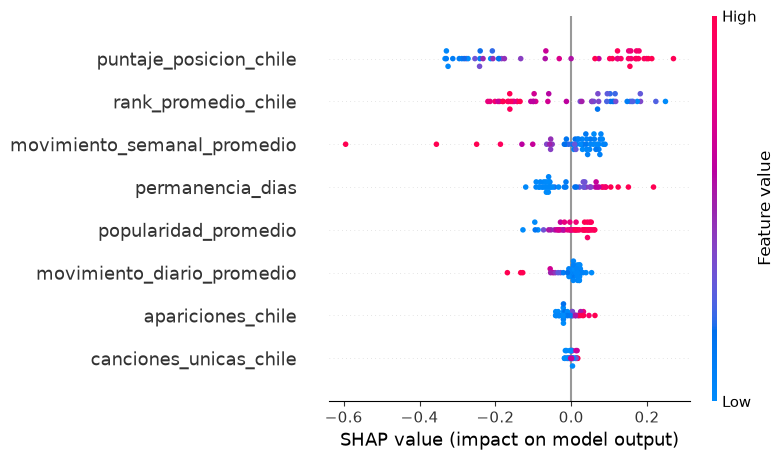

In [76]:
# Visualización complementaria SHAP

shap.summary_plot(
    shap_values_array,
    X_explicar,
    feature_names=variables_modelo
)

### Interpretación complementaria del gráfico SHAP summary plot

El gráfico SHAP summary plot complementa la tabla de importancia promedio absoluta, ya que permite observar no solo qué variables influyen más en el modelo, sino también la dirección aproximada de esa influencia. En el gráfico, cada punto representa un artista del conjunto explicado, el color indica si el valor de la variable es alto o bajo, y la posición horizontal muestra si ese valor empuja la predicción hacia una mayor o menor probabilidad de pertenecer a la clase de alta señal digital local en Spotify.

En `rank_promedio_chile`, se observa que valores más altos tienden a ubicarse hacia la izquierda del gráfico, lo que reduce la probabilidad estimada de alta señal digital local. Esto es coherente con la lógica del ranking, ya que un ranking promedio más alto representa una peor posición en Spotify Chile. Por el contrario, valores más bajos de ranking promedio tienden a favorecer la clasificación positiva.

En `puntaje_posicion_chile`, los valores altos aparecen principalmente hacia la derecha del gráfico, lo que indica que un mayor puntaje de posición contribuye positivamente a la clasificación de alta señal digital local. Esto confirma que el modelo considera relevante la posición alcanzada por los artistas dentro del ranking chileno.

También se observa que variables como `permanencia_dias` y `apariciones_chile` tienden a aportar positivamente cuando sus valores son altos, lo que resulta coherente con la interpretación del problema: artistas con más permanencia y más apariciones en rankings de Spotify Chile presentan mayor señal digital local.

En conjunto, el gráfico refuerza que el modelo basa sus predicciones principalmente en variables asociadas al posicionamiento, permanencia y presencia en rankings de Spotify Chile. Sin embargo, esta explicación sigue limitada a las variables disponibles en el dataset, por lo que no debe interpretarse como una medición directa de convocatoria real, venta de entradas o asistencia a eventos.

### Interpretación de la explicabilidad con SHAP

La tabla y los gráficos anteriores ordenan las variables según su importancia promedio absoluta para la clasificación del modelo seleccionado. Las variables ubicadas en los primeros lugares son las que más contribuyen, en promedio, a diferenciar los perfiles técnicos construidos con los datos de Spotify Chile.

Las variables con menor importancia relativa no deben considerarse irrelevantes: su aporte es menor dentro de esta ejecución y en relación con las demás variables disponibles. La visualización de importancia promedio absoluta permite identificar magnitud, mientras que el gráfico SHAP complementario ayuda a observar la dirección aproximada de la influencia.

Estos resultados explican la fidelidad del modelo a una etiqueta técnica derivada de K-Means. No constituyen una medición directa de convocatoria real, venta de entradas ni asistencia a eventos.

### 3.12 Revisión de casos particulares del conjunto de prueba

In [77]:
casos_prueba = base_modelo_artistas.loc[
    X_test.index,
    ["artists", "cluster", "perfil_cluster", "alto_potencial"] + variables_modelo
].copy()

casos_prueba["probabilidad_alta_senal_spotify"] = y_test_prob
casos_prueba["clase_predicha"] = y_test_pred
casos_prueba["clasificacion_correcta"] = (
    casos_prueba["alto_potencial"] == casos_prueba["clase_predicha"]
)

casos_prueba = casos_prueba.sort_values(
    by="probabilidad_alta_senal_spotify",
    ascending=False
)

casos_prueba_resumen = casos_prueba[
    [
        "artists",
        "perfil_cluster",
        "alto_potencial",
        "clase_predicha",
        "clasificacion_correcta",
        "probabilidad_alta_senal_spotify",
        "apariciones_chile",
        "rank_promedio_chile",
        "permanencia_dias",
        "puntaje_posicion_chile"
    ]
].copy()

casos_prueba_resumen["probabilidad_alta_senal_spotify"] = casos_prueba_resumen[
    "probabilidad_alta_senal_spotify"
].round(4)

print("Casos con mayor probabilidad de alta señal digital local en Spotify:")
display(casos_prueba_resumen.head(10))

print("Casos con menor probabilidad de alta señal digital local en Spotify:")
display(casos_prueba_resumen.tail(10))

Casos con mayor probabilidad de alta señal digital local en Spotify:


,artists,perfil_cluster,alto_potencial,clase_predicha,clasificacion_correcta,probabilidad_alta_senal_spotify,apariciones_chile,rank_promedio_chile,permanencia_dias,puntaje_posicion_chile
128,Jere Klein,Artistas consolidados de alto desempeño local,1,1,True,1.0000,3792,21.359705,581,50
3,ATL Jacob,Presencia sostenida en rankings chilenos,1,1,True,1.0000,489,19.498978,489,48
242,Nickoog Clk,Presencia sostenida en rankings chilenos,1,1,True,1.0000,798,27.199248,421,50
241,Nicki Nicole,Presencia sostenida en rankings chilenos,1,1,True,1.0000,387,21.819121,236,48
339,Yorghaki,Presencia sostenida en rankings chilenos,1,1,True,0.9999,154,15.025974,154,46
9,Alleh,Presencia sostenida en rankings chilenos,1,1,True,0.9999,154,15.025974,154,46
174,Lady Gaga,Presencia sostenida en rankings chilenos,1,1,True,0.9999,284,23.619718,266,45
33,Beéle,Presencia sostenida en rankings chilenos,1,1,True,0.9999,282,15.734043,157,50
70,Darell,Presencia sostenida en rankings chilenos,1,1,True,0.9998,164,22.463415,164,47
245,Nysix Music,Presencia sostenida en rankings chilenos,1,1,True,0.9997,228,24.719298,228,46


Casos con menor probabilidad de alta señal digital local en Spotify:


,artists,perfil_cluster,alto_potencial,clase_predicha,clasificacion_correcta,probabilidad_alta_senal_spotify,apariciones_chile,rank_promedio_chile,permanencia_dias,puntaje_posicion_chile
275,Rafaga,Aparición puntual o comportamiento emergente,0,0,True,0.0,4,15.0,2,43
301,Sonora Malecón,Aparición puntual o comportamiento emergente,0,0,True,0.0,1,19.0,1,32
77,Dj Agus Lima,Aparición puntual o comportamiento emergente,0,0,True,0.0,2,2.0,2,49
173,La Sonora De Tommy Rey,Aparición puntual o comportamiento emergente,0,0,True,0.0,8,12.0,2,46
177,Latto,Baja presencia o menor posicionamiento local,0,0,True,0.0,2,46.0,2,9
279,Remers,Baja presencia o menor posicionamiento local,0,0,True,0.0,2,40.0,2,14
231,Myriam Hernandez,Baja presencia o menor posicionamiento local,0,0,True,0.0,1,48.0,1,3
81,Drago200,Baja presencia o menor posicionamiento local,0,0,True,0.0,1,50.0,1,1
2,AKRIILA,Baja presencia o menor posicionamiento local,0,0,True,0.0,1,39.0,1,12
102,Fuego,Baja presencia o menor posicionamiento local,0,0,True,0.0,1,47.0,1,4


### Interpretación de casos particulares

La revisión de casos particulares permite observar que los artistas con mayor probabilidad estimada de alta señal digital local en Spotify corresponden principalmente a perfiles con presencia sostenida o consolidada en rankings chilenos. En estos casos, el modelo asigna probabilidades altas y clasificaciones correctas, lo que resulta coherente con variables como apariciones en Chile, ranking promedio, permanencia en rankings y puntaje de posición.

Entre los casos con mayor probabilidad se observan artistas o colaboraciones con presencia relevante en el ranking chileno, como Myke Towers, Bad Bunny y distintas colaboraciones urbanas. Estos ejemplos muestran que el modelo tiende a clasificar con alta señal digital local a artistas que presentan una presencia frecuente o estable dentro de Spotify Chile.

Por otra parte, los casos con menor probabilidad estimada corresponden principalmente a artistas o colaboraciones con menor presencia, apariciones puntuales o posicionamiento más bajo dentro del ranking chileno. En estos casos, el modelo asigna una probabilidad menor de pertenecer a la clase de alta señal digital local, lo que se relaciona con métricas como menor cantidad de apariciones, menor permanencia o ranking promedio menos favorable.

Esta revisión complementa las métricas globales del modelo, ya que permite observar ejemplos concretos del conjunto de prueba y verificar que las predicciones son consistentes con los perfiles definidos previamente. Sin embargo, estos resultados deben interpretarse con cautela, ya que la clasificación corresponde a una etiqueta técnica derivada de los clusters y de las variables disponibles en Spotify Chile. Por lo tanto, no representa una medición directa de convocatoria real, venta de entradas o capacidad de llenar recintos.

### 3.13 Limitaciones, alcance del modelo y mejoras futuras

A pesar del buen desempeño observado en las métricas de validación y prueba, el modelo presenta limitaciones importantes que deben considerarse al interpretar sus resultados. La principal limitación es que la variable objetivo utilizada no corresponde a una medición real de convocatoria, ventas de entradas o asistencia a eventos, sino a una etiqueta técnica construida a partir de los clusters obtenidos previamente. Por esta razón, los resultados deben entenderse como una clasificación de perfiles de señal digital local en Spotify, y no como una predicción directa de éxito comercial o capacidad real de llenar un recinto.

En este sentido, la categoría de mayor señal no debe interpretarse como que un artista necesariamente llenará un estadio, ni la categoría de menor señal debe interpretarse como que un artista no tiene convocatoria. La clasificación depende de las variables disponibles en el dataset, principalmente presencia en rankings diarios de Spotify Chile, permanencia, posición promedio, mejor posición alcanzada, apariciones y movimientos en el ranking. Por lo tanto, artistas con trayectoria, reconocimiento popular o buena convocatoria en ciertos circuitos podrían aparecer con menor señal si no presentan una presencia sostenida en el Top 50 diario de Spotify Chile durante el periodo analizado.

Además, el modelo no incorpora otras fuentes relevantes de consumo musical y convocatoria, como Apple Music, YouTube, Billboard, rankings radiales, interacción en redes sociales, venta de entradas, asistencia histórica a eventos, actividad en TikTok o comportamiento de audiencias en plataformas distintas a Spotify. Tampoco considera variables contextuales propias de la producción de eventos, como ciudad, tipo de recinto, precio de entradas, género musical, temporada, costos de contratación, edad del público objetivo o escala del evento. Estas variables son relevantes porque un artista puede tener alta convocatoria en espacios específicos, festivales locales, eventos comunales, casinos, fiestas tropicales o recintos de menor tamaño, aunque no destaque fuertemente en los rankings diarios de Spotify.

Como mejora futura, se propone construir un índice multifuente que incorpore señales de distintas plataformas y contextos de consumo musical. Esto permitiría diferenciar entre artistas con alta señal digital en Spotify y artistas con convocatoria relevante en circuitos específicos, géneros particulares o recintos de menor escala. Para ello, podrían integrarse datos de Spotify, Apple Music, YouTube, TikTok, Instagram, rankings radiales, Billboard y venta histórica de entradas.

Una segunda mejora consiste en incorporar información real de eventos, como asistencia, venta de tickets, ciudad, recinto, fecha, tipo de evento y precio promedio de entrada. Con este tipo de datos sería posible construir una variable objetivo más cercana al fenómeno real de convocatoria, permitiendo evaluar si las señales digitales efectivamente se relacionan con la asistencia a eventos musicales.

Una tercera mejora consiste en ampliar la validación del modelo mediante nuevas particiones de entrenamiento y prueba, validación cruzada y actualización periódica con nuevos rankings de Spotify. Esto permitiría evaluar si el desempeño observado se mantiene estable ante nuevos datos y reduciría el riesgo de depender de una única partición del dataset.

Finalmente, también se podría comparar la red neuronal MLP con otros modelos supervisados, como Random Forest, Gradient Boosting o regresión logística. Esta comparación permitiría evaluar si una arquitectura más simple logra resultados similares con mayor explicabilidad, o si el uso de redes neuronales aporta una mejora real en el desempeño del sistema.